# PSI Field Lab v3 — Multimodal Anomaly Triage with Evidence-Bounded LLM Review
**Paranormal 3:33 Research Lab**

This notebook is an exploratory research pipeline for prioritizing field events that deserve additional human review. It combines physiological signals, EEG-derived features, audio, body-camera motion, environmental context, repeatability across participants, unsupervised machine learning, and an evidence-bounded LLM reviewer.

> **Scientific boundary:** a high score means *unusual under the recorded conditions*, not *paranormal*. The notebook ranks evidence for follow-up while keeping observation, interpretation, and causal claims separate.

### What changed from v2
| v2 problem | v3 fix |
|---|---|
| Events were scored from a pre-annotated table only | Events are also **detected from the raw 10-s windows** (participant-level baselines, artifact handling, audio-vs-physiology lag) |
| Signal quality and low motion were *evidence points* | They are now **gates** (eligibility filters), not evidence |
| Site properties (no electricity, repeatability) were added to every event score | **Event score** and **site score** are computed separately; no site feedback into events |
| "Not reviewed" audio counted the same as "nothing detected" | Audio coverage is reported and missing reviews are treated as missing |
| The LLM received the final triage score inside the record | The LLM sees **observations only**: no derived scores, no verdict fields |
| LLM output was free text | Output is **structured JSON**, validated, repeated for consistency, and checked for invented numbers |
| No way to know whether the pipeline works | A separate `ground_truth.csv` (generator labels) is used for **evaluation only** |

### Research questions
1. Which events show convergent deviations across independent modalities?
2. Do unusual events repeat across *different* participants at the same site?
3. Can an unsupervised model identify the same candidates without using paranormal labels?
4. How much do environmental confounders and independent audio review change the ranking?
5. Are the final rankings robust to reasonable changes in scoring weights?
6. **(new)** Does the LLM reviewer agree with the quantitative triage, and does it stay inside the evidence?

### Reproducibility
- Fixed random seed: `333`
- Credentials loaded from `.env`; never hard-coded
- Transparent rule-based thresholds are kept separate from ML scores
- Ground-truth labels are loaded in a clearly marked evaluation section and never enter any score or prompt

## 1. Environment and data location

The notebook supports two data sources:

1. local CSV files in `PSI_DATA_DIR`, or
2. Neon/PostgreSQL tables when `USE_POSTGRES=true`.

For the current PSI Field Lab demo, the operational tables live under `pleyades/psi_lab`:

- `sessions`
- `sensor_windows`
- `events`
- `audio_reviews`
- `ground_truth` — synthetic evaluation only; never passed to scoring or the LLM.

Outputs are still exported as CSV/JSON files under `PSI_OUTPUT_DIR` so collaborators can test the package without connecting to the database.


In [1]:
# Purpose: Install notebook dependencies used for LLM access, environment-variable loading, and PostgreSQL/Neon access.
# In Google Colab this is safe. In a local venv you can comment this cell and install from requirements.txt instead.
import sys, subprocess

REQUIRED_PACKAGES = [
    "ollama",
    "python-dotenv",
    "sqlalchemy",
    "psycopg2-binary",
]

subprocess.run([sys.executable, "-m", "pip", "install", "-q", *REQUIRED_PACKAGES], check=False)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
deepnote-toolkit 2.6.0 requires cryptography<51,>=50.0.0, but you have cryptography 46.0.7 which is incompatible.
deepnote-toolkit 2.6.0 requires pillow<13,>=12.3.0, but you have pillow 12.2.0 which is incompatible.
deepnote-toolkit 2.6.0 requires pyasn1<0.7,>=0.6.4, but you have pyasn1 0.6.3 which is incompatible.
deepnote-toolkit 2.6.0 requires pyopenssl<27,>=26.4.0, but you have pyopenssl 26.2.0 which is incompatible.
deepnote-toolkit 2.6.0 requires snowflake-connector-python<5,>=4.7.2, but you have snowflake-connector-python 4.6.0 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


CompletedProcess(args=['/root/venv/bin/python', '-m', 'pip', 'install', '-q', 'ollama', 'python-dotenv', 'sqlalchemy', 'psycopg2-binary'], returncode=0)

In [2]:
# Purpose: Show where the notebook is running and which data/.env locations are visible.
from pathlib import Path

candidate_dirs = [Path.cwd() / "paranormal", Path.cwd().parent / "paranormal", Path("/work/paranormal")]

print("Current working directory:", Path.cwd())
for folder in candidate_dirs:
    print(f"{folder}: exists={folder.is_dir()} | .env={(folder / '.env').is_file()} | .env.example={(folder / '.env.example').is_file()}")


Current working directory: /datasets/_deepnote_work
/work exists: True
/work/paranormal exists: True
.env exists: True
.env is file: True
Internal resolved path: /datasets/_deepnote_work/paranormal/.env

Files found in /work/paranormal:
 - .env
 - README.md
 - audio_reviews.csv
 - events.csv
 - ground_truth.csv
 - sensor_windows.csv
 - sessions.csv


In [3]:
# Purpose: Import core libraries, load the .env file (local, Colab or Deepnote),
# resolve CSV paths, and define CSV/PostgreSQL access.

import os
import json
import re
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

try:
    from sqlalchemy import create_engine, text
except Exception as exc:
    create_engine = None
    text = None
    _sqlalchemy_import_error = exc
else:
    _sqlalchemy_import_error = None


# ---------------------------------------------------------------------
# Locate and load the environment file (works on any machine)
# ---------------------------------------------------------------------
# Search order:
#   1. PSI_ENV_FILE environment variable (explicit override)
#   2. ./paranormal/.env    (repository root = working directory)
#   3. ../paranormal/.env   (notebook opened from a subfolder)
#   4. /work/paranormal/.env (Deepnote project layout)

def resolve_env_path() -> Path:
    candidates = []
    if os.getenv("PSI_ENV_FILE"):
        candidates.append(Path(os.environ["PSI_ENV_FILE"]).expanduser())
    candidates += [
        Path.cwd() / "paranormal" / ".env",
        Path.cwd().parent / "paranormal" / ".env",
        Path("/work/paranormal/.env"),
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        "No .env file found. Copy paranormal/.env.example to paranormal/.env "
        "(or set PSI_ENV_FILE). Searched:\n"
        + "\n".join(f"  - {c}" for c in candidates)
    )


ENV_PATH = resolve_env_path()

load_dotenv(
    dotenv_path=str(ENV_PATH),
    override=True,
)


# ---------------------------------------------------------------------
# Resolve data and temporary output directories
# ---------------------------------------------------------------------

SEED = int(os.getenv("SEED", "333"))

# Default: the folder that contains the .env file (paranormal/).
# Relative paths in .env are resolved against the working directory.
DATA_DIR = Path(
    os.getenv(
        "PSI_DATA_DIR",
        str(ENV_PATH.parent),
    )
).expanduser()

# PSI_OUTPUT_DIR is the root. Every full notebook execution gets its own
# timestamped child directory so one run never overwrites another.
RUN_STARTED_AT_UTC = datetime.now(timezone.utc)
RUN_ID = RUN_STARTED_AT_UTC.strftime("%Y%m%d_%H%M%S_UTC")

OUTPUT_ROOT = Path(
    os.getenv(
        "PSI_OUTPUT_DIR",
        "psi_lab_v3_outputs",
    )
).expanduser()

OUTPUT_DIR = OUTPUT_ROOT / f"output_{RUN_ID}"

if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        "El directorio de datos configurado no existe.\n"
        f"PSI_DATA_DIR: {DATA_DIR}\n"
        f".env loaded from: {ENV_PATH}"
    )

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 80)

try:
    display
except NameError:
    display = print


def env_bool(name: str, default: bool = False) -> bool:
    value = os.getenv(name)

    if value is None:
        return default

    return value.strip().lower() in {
        "1",
        "true",
        "yes",
        "y",
        "on",
    }


USE_POSTGRES = env_bool("USE_POSTGRES", False)
DATABASE_URL = os.getenv("DATABASE_URL")
POSTGRES_SCHEMA = os.getenv("POSTGRES_SCHEMA", "psi_lab")
DB_ECHO = env_bool("DB_ECHO", False)
DB_WRITE_MODE = os.getenv("DB_WRITE_MODE", "append")

TABLE_NAMES = {
    "sessions": os.getenv(
        "TABLE_SESSIONS",
        "sessions",
    ),
    "sensor_windows": os.getenv(
        "TABLE_SENSOR_WINDOWS",
        "sensor_windows",
    ),
    "events": os.getenv(
        "TABLE_EVENTS",
        "events",
    ),
    "audio_reviews": os.getenv(
        "TABLE_AUDIO_REVIEWS",
        "audio_reviews",
    ),
    "ground_truth": os.getenv(
        "TABLE_GROUND_TRUTH",
        "ground_truth",
    ),
    "feature_scores": os.getenv(
        "TABLE_FEATURE_SCORES",
        "feature_scores",
    ),
    "llm_reviews": os.getenv(
        "TABLE_LLM_REVIEWS",
        "llm_reviews",
    ),
    "pipeline_runs": os.getenv(
        "TABLE_PIPELINE_RUNS",
        "pipeline_runs",
    ),
}

_IDENT_RE = re.compile(
    r"^[A-Za-z_][A-Za-z0-9_]*$"
)


def sql_ident(value: str) -> str:
    """Validate schema and table names used in SQL statements."""

    if not _IDENT_RE.match(value):
        raise ValueError(
            f"Unsafe SQL identifier: {value!r}"
        )

    return value


_engine = None


def get_engine():
    """Create one reusable SQLAlchemy engine."""

    global _engine

    if not USE_POSTGRES:
        return None

    if not DATABASE_URL:
        raise RuntimeError(
            "USE_POSTGRES=true but DATABASE_URL "
            "is not configured."
        )

    if create_engine is None:
        raise RuntimeError(
            "SQLAlchemy is not available. Install "
            "sqlalchemy and psycopg2-binary.\n"
            f"Error: {_sqlalchemy_import_error}"
        )

    if _engine is None:
        _engine = create_engine(
            DATABASE_URL,
            echo=DB_ECHO,
            pool_pre_ping=True,
        )

    return _engine


def read_research_table(
    logical_name: str,
) -> pd.DataFrame:
    """
    Read a research table from PostgreSQL when enabled;
    otherwise read its CSV file.
    """

    table_name = TABLE_NAMES.get(
        logical_name,
        logical_name,
    )

    if USE_POSTGRES:
        schema = sql_ident(POSTGRES_SCHEMA)
        table = sql_ident(table_name)

        query = (
            f'SELECT * FROM "{schema}"."{table}"'
        )

        with get_engine().connect() as conn:
            return pd.read_sql_query(
                query,
                conn,
            )

    csv_path = (
        DATA_DIR / f"{logical_name}.csv"
    )

    if not csv_path.is_file():
        raise FileNotFoundError(
            f"CSV not found: {csv_path}"
        )

    return pd.read_csv(csv_path)


def write_research_table(
    df: pd.DataFrame,
    logical_name: str,
    if_exists: str | None = None,
):
    """
    Optionally persist derived tables to PostgreSQL.
    """

    if not USE_POSTGRES:
        return

    table_name = sql_ident(
        TABLE_NAMES.get(
            logical_name,
            logical_name,
        )
    )

    schema = sql_ident(POSTGRES_SCHEMA)
    mode = if_exists or DB_WRITE_MODE

    with get_engine().begin() as conn:
        conn.execute(
            text(
                f'CREATE SCHEMA IF NOT EXISTS "{schema}"'
            )
        )

    df.to_sql(
        table_name,
        get_engine(),
        schema=schema,
        if_exists=mode,
        index=False,
        method="multi",
        chunksize=1000,
    )


# ---------------------------------------------------------------------
# Validate required CSV files
# ---------------------------------------------------------------------

if not USE_POSTGRES:
    required_csv_files = [
        "sessions.csv",
        "sensor_windows.csv",
        "events.csv",
        "audio_reviews.csv",
        "ground_truth.csv",
    ]

    missing_csv_files = [
        filename
        for filename in required_csv_files
        if not (DATA_DIR / filename).is_file()
    ]

    if missing_csv_files:
        missing_list = "\n".join(
            f"  - {filename}"
            for filename in missing_csv_files
        )

        raise FileNotFoundError(
            "The following CSV files were not found "
            f"en {DATA_DIR}:\n"
            f"{missing_list}"
        )


print(
    "Runtime environment:",
    os.getenv("ENVIRONMENT", "local"),
)
print("Environment file:", ENV_PATH)
print(
    "Data source:",
    "PostgreSQL/Neon"
    if USE_POSTGRES
    else "CSV files",
)
print("Data directory:", DATA_DIR)
print("Run ID:", RUN_ID)
print("Output root:", OUTPUT_ROOT)
print("Run output directory:", OUTPUT_DIR)

if USE_POSTGRES:
    print("Postgres schema:", POSTGRES_SCHEMA)
    print(
        "Database URL configured:",
        bool(DATABASE_URL),
    )
else:
    print(
        "Required CSV files found:",
        len(required_csv_files),
    )

Runtime environment: deepnote
Environment file: /work/paranormal/.env
Data source: PostgreSQL/Neon
Data directory: /work/paranormal
Run ID: 20260913_050900_UTC
Output root: /tmp/psi_lab_v3_outputs
Run output directory: /tmp/psi_lab_v3_outputs/output_20260913_050900_UTC
Postgres schema: psi_lab
Database URL configured: True


## 2. Private LLM configuration
The LLM is used only as a **review assistant**. It is not allowed to infer paranormal causation. Credentials are loaded from environment variables so the notebook can be shared without exposing secrets.

`LLM_MODE` resolves to:
- `live` — a remote Ollama endpoint answered the connection test;
- `mock` — no endpoint available; a deterministic stand-in returns schema-valid JSON so every downstream cell (parsing, validation, evaluation) can still be exercised. Mock outputs are clearly labelled and must never be presented as model results.

In [4]:
# Purpose: Load private LLM configuration without hard-coding API credentials in the notebook.
OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL")
OLLAMA_API_KEY = os.getenv("OLLAMA_API_KEY")
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL")
LLM_MODE = os.getenv("PSI_LLM_MODE", "auto")  # auto | live | mock
LLM_TEMPERATURE = float(os.getenv("LLM_TEMPERATURE", "0"))

print("LLM mode requested:", LLM_MODE)
print("Host configured:", bool(OLLAMA_BASE_URL))
print("Model:", OLLAMA_MODEL)
print("API key loaded:", bool(OLLAMA_API_KEY))
print("LLM temperature:", LLM_TEMPERATURE)


LLM mode requested: live
Host configured: True
Model: gemma4:latest
API key loaded: True
LLM temperature: 0.0


In [5]:
# Purpose: Create the remote Ollama client and verify the connection with a controlled prompt.
# If PSI_LLM_MODE=live, connection failure is a hard error so we do not accidentally present mock results as live LLM output.
client = None

if LLM_MODE not in ("auto", "live", "mock"):
    raise ValueError("PSI_LLM_MODE must be one of: auto, live, mock")

if LLM_MODE in ("auto", "live") and OLLAMA_BASE_URL and OLLAMA_MODEL:
    try:
        from ollama import Client

        headers = {"Authorization": f"Bearer {OLLAMA_API_KEY}"} if OLLAMA_API_KEY else None
        client = Client(host=OLLAMA_BASE_URL, headers=headers)

        ping = client.chat(
            model=OLLAMA_MODEL,
            messages=[{"role": "user", "content": "Reply with exactly: PSI Field Lab connection successful."}],
            options={"temperature": LLM_TEMPERATURE},
        )
        print(ping["message"]["content"])
        LLM_MODE = "live"
    except Exception as exc:
        client = None
        if LLM_MODE == "live":
            raise RuntimeError(
                "PSI_LLM_MODE=live but the Ollama connection failed. "
                "Check OLLAMA_BASE_URL, OLLAMA_MODEL and OLLAMA_API_KEY."
            ) from exc
        print("LLM connection failed; falling back to mock mode:", exc)
        LLM_MODE = "mock"
else:
    if LLM_MODE == "live":
        raise RuntimeError("PSI_LLM_MODE=live but OLLAMA_BASE_URL or OLLAMA_MODEL is missing.")
    LLM_MODE = "mock"

print("LLM_MODE =", LLM_MODE)


PSI Field Lab connection successful.
LLM_MODE = live


## 3. Load the research tables

Four operational datasets drive the pipeline:

- `sessions` — site/session metadata and protocol conditions
- `sensor_windows` — 10-second windowed sensor measurements
- `events` — event-level multimodal features and field observations
- `audio_reviews` — independent human review of audio evidence

The notebook can now read those tables from either:

1. local CSV files in `PSI_DATA_DIR`, or  
2. Neon/PostgreSQL under `POSTGRES_SCHEMA`, when `USE_POSTGRES=true`.

CSV exports remain the default output format for sharing the demo package with external reviewers.

`ground_truth` is **not** loaded here. It is loaded only in Section 12 (evaluation), after every score and every prompt has been produced.


In [6]:
# Purpose: Load the four core operational tables from CSV or PostgreSQL/Neon.
sessions = read_research_table("sessions")
sensor_windows = read_research_table("sensor_windows")
events = read_research_table("events")
audio_reviews = read_research_table("audio_reviews")

# Normalize date/time columns so the rest of the notebook behaves the same from CSV or Postgres.
if "session_date" in sessions.columns:
    sessions["session_date"] = pd.to_datetime(sessions["session_date"]).dt.strftime("%Y-%m-%d")
if "start_time_local" in sessions.columns:
    original_start_time = sessions["start_time_local"].astype(str)
    parsed_start_time = pd.to_datetime(original_start_time, errors="coerce").dt.strftime("%H:%M")
    sessions["start_time_local"] = parsed_start_time.fillna(original_start_time.str[:5])

for name, df in [("sessions", sessions), ("sensor_windows", sensor_windows),
                 ("events", events), ("audio_reviews", audio_reviews)]:
    print(f"{name:15s} {df.shape}")

# Keep a portable source-table CSV snapshot for collaborators who will not connect to the database.
source_export_dir = OUTPUT_DIR / "source_tables_csv"
source_export_dir.mkdir(parents=True, exist_ok=True)
for name, df in [("sessions", sessions), ("sensor_windows", sensor_windows),
                 ("events", events), ("audio_reviews", audio_reviews)]:
    df.to_csv(source_export_dir / f"{name}.csv", index=False)

print(f"Source table CSV snapshot exported to: {source_export_dir.resolve()}")


sessions        (162, 33)
sensor_windows  (28122, 29)
events          (220, 25)
audio_reviews   (160, 17)
Source table CSV snapshot exported to: /tmp/psi_lab_v3_outputs/output_20260913_050900_UTC/source_tables_csv


### 3.1 Data integrity and schema checks
Verify sizes, foreign keys, uniqueness, and durations before anything is scored. A failure here should stop interpretation until the data issue is resolved.

In [7]:
# Purpose: Run relational and data-quality checks before treating any ranking as meaningful.
ML_FEATURES = [
    "hr_delta_bpm_vs_pre_event", "rmssd_delta_pct_vs_pre_event", "beta_delta_pct_vs_pre_event",
    "audio_peak_dbfs", "audio_transient_count", "bodycam_motion_score", "environmental_noise_db",
]

assert sensor_windows["session_id"].isin(sessions["session_id"]).all()
assert events["session_id"].isin(sessions["session_id"]).all()
assert audio_reviews["event_id"].isin(events["event_id"]).all()
assert events["event_id"].is_unique, "Duplicate event_id values detected."
assert audio_reviews["event_id"].is_unique, "An event has more than one audio review."
assert (events["event_end_sec"] >= events["event_start_sec"]).all(), "Negative event duration detected."
assert events[ML_FEATURES].notna().all().all(), "Missing values detected in ML features."
assert np.allclose(sensor_windows[["muse_delta_rel", "muse_theta_rel", "muse_alpha_rel", "muse_beta_rel", "muse_gamma_rel"]].sum(axis=1), 1, atol=1e-3)

print("All integrity checks passed.")
print(f"Events: {len(events)} | Sites: {events['site_id'].nunique()} | Participants: {events['participant_id'].nunique()}")

All integrity checks passed.
Events: 220 | Sites: 15 | Participants: 10


In [8]:
# Purpose: Report audio-review coverage by event type so that a missing review is never confused with a negative review.
events["audio_reviewed"] = events["event_id"].isin(audio_reviews["event_id"])
coverage = (
    events.groupby("event_type")["audio_reviewed"]
    .agg(events="size", reviewed="sum")
    .assign(coverage_pct=lambda d: (100 * d["reviewed"] / d["events"]).round(1))
    .sort_values("coverage_pct", ascending=False)
)
display(coverage)

,events,reviewed,coverage_pct
event_type,,,
audio_transient,32,32,100.0
environmental_or_audio_event,10,10,100.0
multimodal_coincidence,48,48,100.0
movement_event,22,19,86.4
physiological_shift,47,30,63.8
single_sensor_deviation,29,14,48.3
light_change,20,7,35.0
protocol_interruption,12,0,0.0


## 4. Single-session walkthrough and visualization
One session is selected so the analyst can see exactly how session metadata, sensor windows, events, and audio reviews connect. The plots are a human-audit layer: a numerical anomaly can still be caused by movement, signal dropout, clipping, or an obvious environmental transition.

In [9]:
# Purpose: Package every evidence stream for one session so plots and manual review stay synchronized.
def get_session_context(session_id):
    session_events = events[events["session_id"] == session_id]
    return {
        "session": sessions[sessions["session_id"] == session_id],
        "sensor_windows": sensor_windows[sensor_windows["session_id"] == session_id],
        "events": session_events,
        "audio_reviews": audio_reviews[audio_reviews["event_id"].isin(session_events["event_id"])],
    }


SESSION_ID = "SITE_14_P01_A"
context = get_session_context(SESSION_ID)
display(context["session"].T.head(20))
display(context["events"][["event_id", "event_start_sec", "event_end_sec", "event_type", "source_modalities",
                           "explanation_status", "observation_text"]])

,139
session_id,SITE_14_P01_A
site_id,SITE_14
site_name,San Aurelio Stone Hacienda
participant_id,P01
trial,A
repeat_of_session_id,
session_date,2026-04-10
start_time_local,18:30
planned_duration_minutes,30
actual_duration_minutes,30


,event_id,event_start_sec,event_end_sec,event_type,source_modalities,explanation_status,observation_text
174,EVT_0175,330,410,multimodal_coincidence,"polar,muse,audio,bodycam",unresolved,Concurrent physiological and EEG change occurr...
175,EVT_0176,580,660,light_change,bodycam,probable,Brief body-camera light-level change detected.
176,EVT_0177,850,920,audio_transient,audio,unresolved,Short audio transient detected without a susta...
177,EVT_0178,1140,1200,physiological_shift,"polar,muse",unresolved,Concurrent physiological and EEG change withou...
178,EVT_0179,1280,1340,physiological_shift,polar,probable,Brief heart-rate / HRV change detected without...


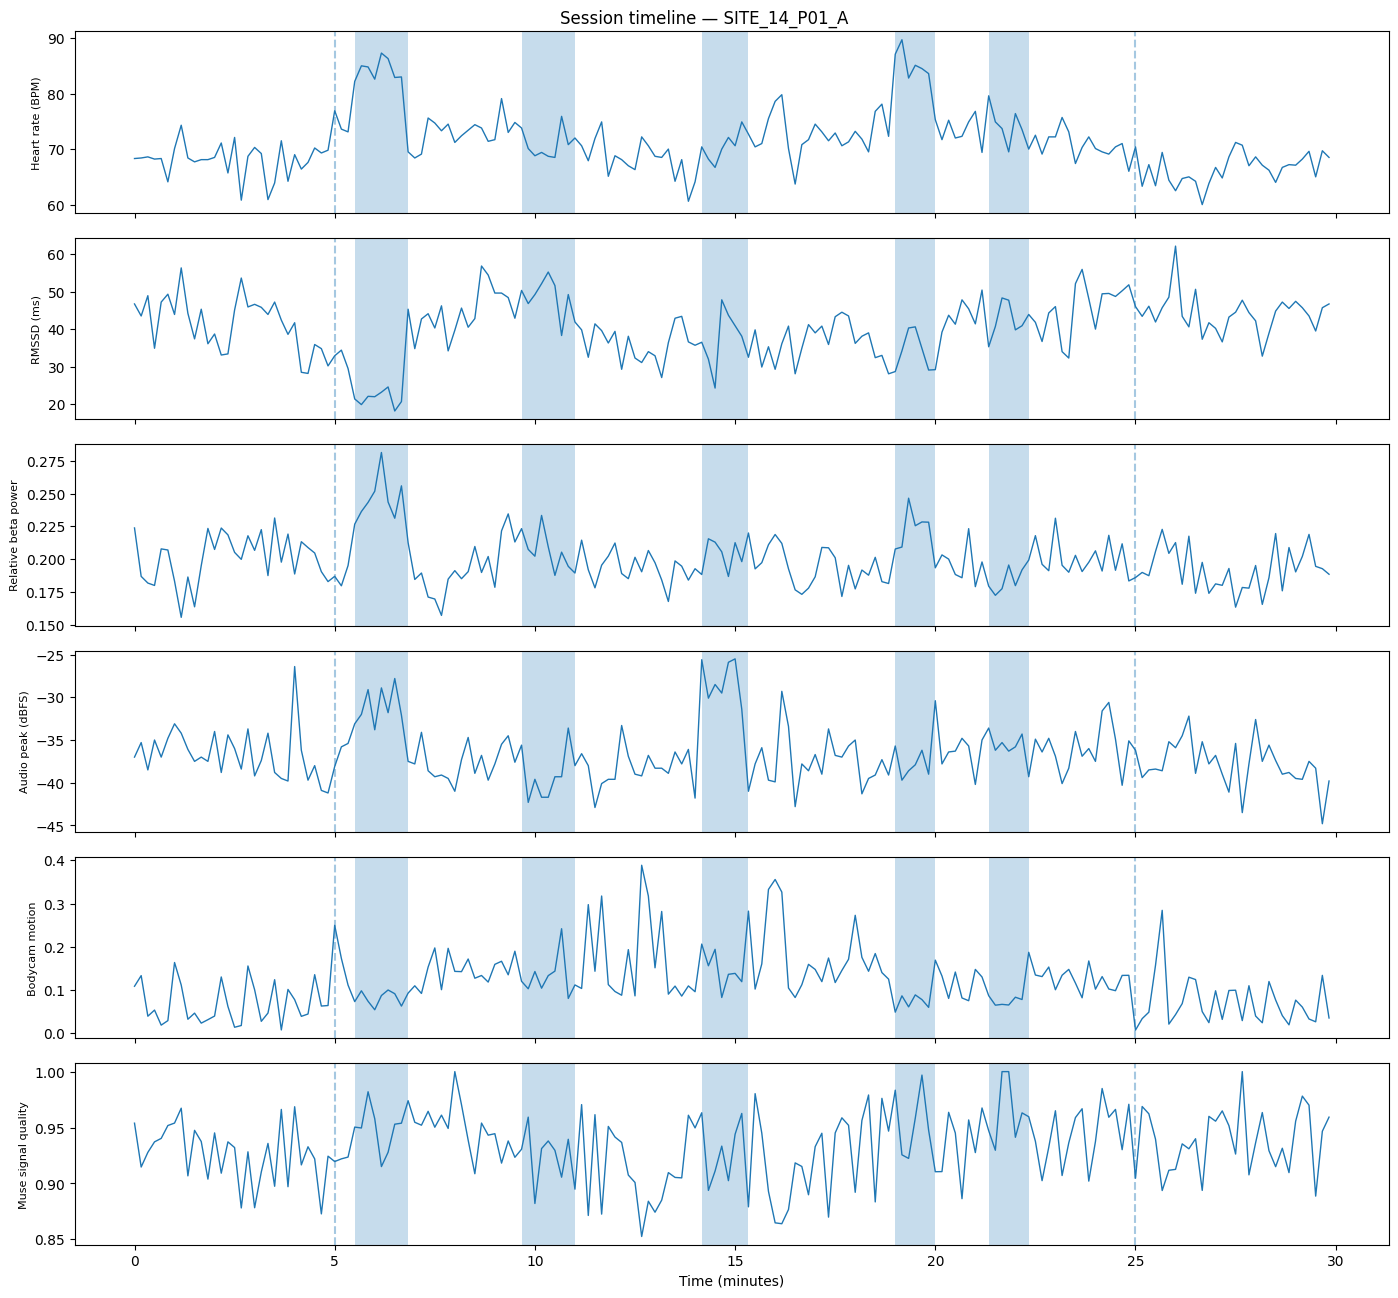

In [10]:
# Purpose: Plot synchronized sensor timelines with event intervals and phase boundaries for the selected session.
def plot_session(session_id, signals=None):
    ctx = get_session_context(session_id)
    w, ev = ctx["sensor_windows"], ctx["events"]
    signals = signals or [
        ("heart_rate_bpm", "Heart rate (BPM)"), ("rmssd_ms", "RMSSD (ms)"),
        ("muse_beta_rel", "Relative beta power"), ("audio_peak_dbfs", "Audio peak (dBFS)"),
        ("bodycam_motion_score", "Bodycam motion"), ("muse_signal_quality", "Muse signal quality"),
    ]
    fig, axes = plt.subplots(len(signals), 1, figsize=(14, 2.2 * len(signals)), sharex=True)
    for ax, (col, label) in zip(axes, signals):
        ax.plot(w["window_start_sec"] / 60, w[col], lw=1)
        for _, e in ev.iterrows():
            ax.axvspan(e["event_start_sec"] / 60, e["event_end_sec"] / 60, alpha=0.25)
        for x in (5, 25):
            ax.axvline(x, ls="--", alpha=0.4)
        ax.set_ylabel(label, fontsize=8)
    axes[-1].set_xlabel("Time (minutes)")
    fig.suptitle(f"Session timeline — {session_id}")
    plt.tight_layout()
    plt.show()


plot_session(SESSION_ID)

## 5. Window-level detection (new in v3)
`events.csv` is a field annotation; it is not the only way to find candidates. This section detects deviations directly from the 10-second windows so the notebook has an *independent* route to the same events.

Method:
1. Each session's **before** phase (baseline station, 5 min) provides a participant-specific mean and SD per signal.
2. Every **during** window gets a z-score per signal (HR ↑, RMSSD ↓, beta ↑).
3. Each signal uses its own SD floor so small-scale features are not accidentally suppressed: HR = 1.0 BPM, RMSSD = 2.0 ms, Muse beta = 0.005 relative power.
4. Windows with artifacts (`artifact_flag`) or Muse quality < 0.75 are excluded from convergence.
5. A **convergence window** has ≥ 2 of the 3 physiological z-scores beyond the threshold with motion ≤ 0.15. Consecutive convergence windows are merged into a segment.
6. For each segment, the **audio lead** is measured: seconds between the first audio transient in the preceding 30 s and the physiological onset. A transient that *precedes* the physiology is consistent with a conventional startle response.


In [11]:
# Purpose: Compute participant-specific baselines from the "before" phase and z-score every "during" window.
# Important fix: each signal has a different natural scale. A single SD floor (for example 0.5)
# suppresses small-scale signals such as muse_beta_rel, whose baseline SD is usually ~0.01-0.02.
SIGNALS = {"heart_rate_bpm": +1, "rmssd_ms": -1, "muse_beta_rel": +1}
STD_FLOORS = {"heart_rate_bpm": 1.0, "rmssd_ms": 2.0, "muse_beta_rel": 0.005}
Z_THRESHOLD = 2.0

baseline = (
    sensor_windows[sensor_windows["phase"] == "before"]
    .groupby("session_id")[list(SIGNALS)]
    .agg(["mean", "std"])
)
baseline.columns = [f"{c}_{s}" for c, s in baseline.columns]

z = sensor_windows.merge(baseline, left_on="session_id", right_index=True, how="left")
zscore_diagnostics = []

for col, sign in SIGNALS.items():
    sd_col = f"{col}_std"
    floor = STD_FLOORS[col]
    denom = z[sd_col].fillna(floor).clip(lower=floor)
    z[f"{col}_std_used"] = denom
    z[f"z_{col}"] = sign * (z[col] - z[f"{col}_mean"]) / denom

    zscore_diagnostics.append({
        "signal": col,
        "direction": "increase" if sign > 0 else "decrease",
        "sd_floor": floor,
        "median_baseline_sd": round(float(baseline[sd_col].median()), 6),
        "min_baseline_sd": round(float(baseline[sd_col].min()), 6),
        "max_z_during": round(float(z.loc[z["phase"] == "during", f"z_{col}"].max()), 3),
    })

zscore_diagnostics = pd.DataFrame(zscore_diagnostics)
display(zscore_diagnostics)

z["usable"] = (~z["artifact_flag"]) & (z["muse_signal_quality"] >= 0.75) & (z["polar_signal_quality"] >= 0.85)
z["n_physio_deviations"] = sum((z[f"z_{c}"] >= Z_THRESHOLD).astype(int) for c in SIGNALS)
z["convergent"] = (
    (z["phase"] == "during")
    & z["usable"]
    & (z["n_physio_deviations"] >= 2)
    & (z["bodycam_motion_score"] <= 0.15)
)

# Guard against the previous bug: beta should be able to contribute to convergence.
assert z.loc[z["phase"] == "during", "z_muse_beta_rel"].max() > Z_THRESHOLD, (
    "Muse beta z-scores never exceed threshold. Check STD_FLOORS['muse_beta_rel']."
)

print("Usable during-phase windows:", int((z["usable"] & (z["phase"] == "during")).sum()), "/", int((z["phase"] == "during").sum()))
print("Convergent windows:", int(z["convergent"].sum()))
print("Physiology deviations by signal:",
      {c: int((z[f'z_{c}'] >= Z_THRESHOLD).sum()) for c in SIGNALS})


,signal,direction,sd_floor,median_baseline_sd,min_baseline_sd,max_z_during
0,heart_rate_bpm,increase,1.000,2.699594,1.375650,11.887
1,rmssd_ms,decrease,2.000,6.255159,3.933646,6.047
2,muse_beta_rel,increase,0.005,0.014150,0.008585,7.596


Usable during-phase windows: 18567 / 18762
Convergent windows: 536
Physiology deviations by signal: {'heart_rate_bpm': 7056, 'rmssd_ms': 2310, 'muse_beta_rel': 1579}


In [12]:
# Purpose: Merge consecutive convergent windows into detected segments and measure the audio lead relative to physiological onset.
def detect_segments(zdf, gap_windows=1, min_windows=2, lookback_sec=30):
    segments = []
    for sid, g in zdf.sort_values(["session_id", "window_start_sec"]).groupby("session_id"):
        g = g.reset_index(drop=True)
        conv = g["convergent"].to_numpy()
        i = 0
        while i < len(g):
            if not conv[i]:
                i += 1
                continue
            j = i
            while j + 1 < len(g) and (conv[j + 1] or (j + 2 < len(g) and conv[j + 2] and gap_windows)):
                j += 1
            seg = g.iloc[i:j + 1]
            if len(seg) >= min_windows:
                onset = int(seg["window_start_sec"].iloc[0])
                pre = g[(g["window_start_sec"] >= onset - lookback_sec) & (g["window_start_sec"] < onset)]
                inside = seg[seg["audio_transient_count"] > 0]
                lead = None
                if (pre["audio_transient_count"] > 0).any():
                    lead = onset - int(pre.loc[pre["audio_transient_count"] > 0, "window_start_sec"].iloc[0])
                elif len(inside):
                    lead = onset - int(inside["window_start_sec"].iloc[0])  # 0 or negative: audio at/after onset
                segments.append(dict(
                    session_id=sid, seg_start_sec=onset, seg_end_sec=int(seg["window_end_sec"].iloc[-1]),
                    n_windows=len(seg),
                    max_z_hr=round(seg["z_heart_rate_bpm"].max(), 2),
                    max_z_rmssd=round(seg["z_rmssd_ms"].max(), 2),
                    max_z_beta=round(seg["z_muse_beta_rel"].max(), 2),
                    mean_motion=round(seg["bodycam_motion_score"].mean(), 3),
                    audio_transients_in_segment=int(seg["audio_transient_count"].sum()),
                    audio_lead_sec=lead,
                ))
            i = j + 1
    return pd.DataFrame(segments)


detected = detect_segments(z)
print("Detected segments:", len(detected))
display(detected.sort_values("max_z_hr", ascending=False).head(10))

Detected segments: 81


,session_id,seg_start_sec,seg_end_sec,n_windows,max_z_hr,max_z_rmssd,max_z_beta,mean_motion,audio_transients_in_segment,audio_lead_sec
66,SITE_14_P08_A,1070,1160,9,11.89,3.79,6.21,0.115,4,-30.0
18,SITE_05_P03_A,890,960,7,9.36,3.76,3.70,0.052,5,10.0
50,SITE_11_P01_A,1060,1080,2,9.16,3.14,2.73,0.099,0,10.0
42,SITE_10_P02_A,430,510,8,8.84,5.31,3.42,0.084,0,NaN
74,SITE_15_P05_A,1100,1160,6,8.73,2.16,5.84,0.068,4,0.0
75,SITE_15_P05_A,1300,1350,5,8.63,4.17,3.88,0.102,1,0.0
53,SITE_12_P04_A,500,570,7,8.30,2.72,3.29,0.047,0,10.0
2,SITE_01_P07_B,870,890,2,8.30,2.45,4.16,0.118,3,0.0
67,SITE_14_P10_A,1070,1150,8,8.16,3.61,4.36,0.082,1,0.0
70,SITE_15_P03_A,420,440,2,7.90,2.68,2.68,0.089,0,NaN


In [13]:
# Purpose: Match detected segments to annotated events by temporal overlap and attach window-derived features to every event.
def overlap(a0, a1, b0, b1):
    return max(0, min(a1, b1) - max(a0, b0))


match_rows = []
for _, e in events.iterrows():
    cand = detected[detected["session_id"] == e["session_id"]]
    best, best_ov = None, 0
    for _, s in cand.iterrows():
        ov = overlap(e["event_start_sec"], e["event_end_sec"], s["seg_start_sec"], s["seg_end_sec"])
        if ov > best_ov:
            best, best_ov = s, ov
    win = z[(z["session_id"] == e["session_id"]) & (z["window_start_sec"] >= e["event_start_sec"]) & (z["window_start_sec"] < e["event_end_sec"])]
    pre = z[(z["session_id"] == e["session_id"]) & (z["window_start_sec"] >= e["event_start_sec"] - 30) & (z["window_start_sec"] < e["event_start_sec"])]
    first_audio = pd.concat([pre, win])
    first_audio = first_audio.loc[first_audio["audio_transient_count"] > 0, "window_start_sec"]
    physio_onset = win.loc[win["n_physio_deviations"] >= 1, "window_start_sec"]  # first window with any physiological deviation
    lead = None
    if len(first_audio) and len(physio_onset):
        lead = int(physio_onset.iloc[0] - first_audio.iloc[0])
    match_rows.append(dict(
        event_id=e["event_id"],
        window_detected=best is not None,
        window_max_z_hr=round(win["z_heart_rate_bpm"].max(), 2),
        window_max_z_rmssd=round(win["z_rmssd_ms"].max(), 2),
        window_max_z_beta=round(win["z_muse_beta_rel"].max(), 2),
        window_usable_fraction=round(win["usable"].mean(), 2),
        window_artifact_windows=int(win["artifact_flag"].sum()),
        audio_lead_sec=lead,
    ))
window_features = pd.DataFrame(match_rows)
events_w = events.merge(window_features, on="event_id", how="left")

print("Annotated events with an overlapping detected segment:", int(events_w["window_detected"].sum()), "/", len(events_w))
print("Detected segments not overlapping any annotated event:",
      len(detected) - sum(any(overlap(e.event_start_sec, e.event_end_sec, s.seg_start_sec, s.seg_end_sec) > 0
                              for _, e in events[events.session_id == s.session_id].iterrows())
                          for _, s in detected.iterrows()))
display(pd.crosstab(events_w["event_type"], events_w["window_detected"]))

Annotated events with an overlapping detected segment: 46 / 220
Detected segments not overlapping any annotated event: 34


window_detected,False,True
event_type,,
audio_transient,29,3
environmental_or_audio_event,10,0
light_change,19,1
movement_event,22,0
multimodal_coincidence,14,34
physiological_shift,39,8
protocol_interruption,12,0
single_sensor_deviation,29,0


## 6. Transparent event evidence score (v3)
Two things that v2 mixed together are now separated:

**Gates** (eligibility — a failed gate removes the event from candidacy, with the reason recorded):
- session eligible for primary analysis;
- signal quality not degraded and ≥ 50% of the event windows usable;
- mean body-camera motion ≤ 0.20;
- no documented environmental match (`environmental_match == "true"` means a conventional source was logged).

**Evidence points** (only for events that pass the gates):
- heart-rate increase ≥ 5 BPM
- RMSSD decrease ≥ 15 %
- beta increase ≥ 8 %
- window-level convergence confirmed by the independent detector
- independent audio support: reviewer found something, no environmental source, Spirit Box off *and* the audio does not precede the physiology by ≥ 10 s

Two multiplicative penalties follow: ×0.85 when the environmental status is *unknown* rather than *false*, and ×0.5 when the audio transient precedes the physiological onset by ≥ 10 s (a conventional startle pattern that only the raw windows can reveal).

Site properties (electricity, traffic, repeatability) are **not** part of the event score any more.

For comparison, the original v2 six-point score is also computed.

In [14]:
# Purpose: Join session conditions and independent audio review to every event.
event_context = events_w.merge(
    sessions[["session_id", "electricity_available", "running_water_available", "traffic_level",
              "weather_condition", "rainfall_mm", "protocol_deviation", "primary_analysis_eligible",
              "site_name", "building_type", "construction_material", "occupancy_status",
              "known_electrical_sources", "known_animals_observed", "investigator_notes"]],
    on="session_id", how="left",
).merge(
    audio_reviews[["event_id", "spirit_box_status", "audio_result", "audible_content", "radio_bleed_possible",
                   "environmental_source_possible", "reviewer_confidence", "explanation_status"]],
    on="event_id", how="left", suffixes=("", "_audio"),
)


def is_true(v):
    return str(v).strip().lower() == "true"


def is_false(v):
    return str(v).strip().lower() == "false"

In [15]:
# Purpose: v2 legacy score (kept for comparison only).
def sensor_evidence_v2(row):
    return int(
        (row["hr_delta_bpm_vs_pre_event"] >= 5) + (row["rmssd_delta_pct_vs_pre_event"] <= -15)
        + (row["beta_delta_pct_vs_pre_event"] >= 8) + (row["audio_transient_count"] >= 1)
        + (row["bodycam_motion_score"] <= 0.15) + (row["signal_quality_summary"] == "good")
    )


event_context["sensor_score_v2"] = event_context.apply(sensor_evidence_v2, axis=1)

In [16]:
# Purpose: v3 gates and evidence points, kept explicit and auditable.
INTERESTING_AUDIO = {"voice_like", "short_transient", "ambiguous_noise"}


def apply_gates(row):
    reasons = []
    if not is_true(row["primary_analysis_eligible"]):
        reasons.append("session_not_eligible")
    if row["signal_quality_summary"] == "degraded" or (row["window_usable_fraction"] < 0.5):
        reasons.append("signal_quality")
    if row["bodycam_motion_score"] > 0.20:
        reasons.append("motion")
    if is_true(row["environmental_match"]):
        reasons.append("documented_environmental_source")
    return ";".join(reasons)


def audio_support(row):
    if pd.isna(row["audio_result"]):
        return np.nan  # not reviewed -> missing, not zero
    if row["audio_result"] not in INTERESTING_AUDIO:
        return 0.0
    if not pd.isna(row["audio_lead_sec"]) and row["audio_lead_sec"] >= 10:
        return 0.0  # audio precedes physiology: startle pattern
    s = 0.4
    s += 0.3 if is_false(row["environmental_source_possible"]) else 0.0
    s += 0.2 if row["spirit_box_status"] == "off" else 0.0
    s += 0.1 if (not pd.isna(row["reviewer_confidence"]) and row["reviewer_confidence"] >= 0.7) else 0.0
    return s


def evidence_points(row):
    pts = {
        "hr": float(row["hr_delta_bpm_vs_pre_event"] >= 5),
        "rmssd": float(row["rmssd_delta_pct_vs_pre_event"] <= -15),
        "beta": float(row["beta_delta_pct_vs_pre_event"] >= 8),
        "window_convergence": float(bool(row["window_detected"])),
    }
    a = audio_support(row)
    pts["audio"] = 0.0 if pd.isna(a) else a
    return pts


event_context["gate_failures"] = event_context.apply(apply_gates, axis=1)
event_context["passes_gates"] = event_context["gate_failures"] == ""
pts = event_context.apply(evidence_points, axis=1, result_type="expand").add_prefix("pt_")
event_context = pd.concat([event_context, pts], axis=1)
event_context["audio_support"] = event_context.apply(audio_support, axis=1)

PT_COLS = list(pts.columns)
event_context["evidence_score_v3"] = np.where(
    event_context["passes_gates"], event_context[PT_COLS].sum(axis=1) / len(PT_COLS), 0.0
)
# ambiguity penalty: environmental status unknown (not false) reduces the score slightly
event_context.loc[event_context["environmental_match"].astype(str).str.lower() == "unknown", "evidence_score_v3"] *= 0.85
# startle penalty: an audio transient that precedes the physiology by >= 10 s is consistent with a conventional startle
event_context["startle_pattern"] = event_context["audio_lead_sec"].fillna(-1) >= 10
event_context.loc[event_context["startle_pattern"], "evidence_score_v3"] *= 0.5
print("Events with a startle timing pattern:", int(event_context["startle_pattern"].sum()))

print("Events passing all gates:", int(event_context["passes_gates"].sum()), "/", len(event_context))
print(event_context["gate_failures"].value_counts().head(8))

Events with a startle timing pattern: 62
Events passing all gates: 85 / 220
gate_failures
                                                               85
documented_environmental_source                                47
motion;documented_environmental_source                         41
signal_quality                                                 28
session_not_eligible;motion;documented_environmental_source    12
motion                                                          6
signal_quality;motion                                           1
Name: count, dtype: int64


In [17]:
# Purpose: Rank events by the v3 evidence score for human inspection.
ranked_v3 = event_context.sort_values(["evidence_score_v3", "sensor_score_v2"], ascending=False)
display(ranked_v3[["event_id", "site_id", "participant_id", "event_type", "evidence_score_v3", "sensor_score_v2",
                   "pt_hr", "pt_rmssd", "pt_beta", "pt_window_convergence", "pt_audio", "audio_lead_sec",
                   "bodycam_motion_score", "environmental_match"]].head(20))

,event_id,site_id,participant_id,event_type,evidence_score_v3,sensor_score_v2,pt_hr,pt_rmssd,pt_beta,pt_window_convergence,pt_audio,audio_lead_sec,bodycam_motion_score,environmental_match
113,EVT_0114,SITE_09,P05,multimodal_coincidence,1.000,6,1.0,1.0,1.0,1.0,1.0,0.0,0.088,false
193,EVT_0194,SITE_14,P08,multimodal_coincidence,1.000,6,1.0,1.0,1.0,1.0,1.0,0.0,0.100,false
198,EVT_0199,SITE_14,P10,multimodal_coincidence,1.000,6,1.0,1.0,1.0,1.0,1.0,0.0,0.082,false
208,EVT_0209,SITE_15,P05,multimodal_coincidence,1.000,6,1.0,1.0,1.0,1.0,1.0,0.0,0.068,false
83,EVT_0084,SITE_07,P02,multimodal_coincidence,0.980,6,1.0,1.0,1.0,1.0,0.9,0.0,0.112,false
144,EVT_0145,SITE_12,P04,multimodal_coincidence,0.980,6,1.0,1.0,1.0,1.0,0.9,0.0,0.049,false
174,EVT_0175,SITE_14,P01,multimodal_coincidence,0.980,6,1.0,1.0,1.0,1.0,0.9,0.0,0.080,false
190,EVT_0191,SITE_14,P07,multimodal_coincidence,0.980,6,1.0,1.0,1.0,1.0,0.9,0.0,0.101,false
209,EVT_0210,SITE_15,P05,multimodal_coincidence,0.980,6,1.0,1.0,1.0,1.0,0.9,0.0,0.102,false
218,EVT_0219,SITE_15,P10,multimodal_coincidence,0.980,6,1.0,1.0,1.0,1.0,0.9,0.0,0.062,false


## 7. Unsupervised anomaly detection
Isolation Forest gives a second ranking that uses only numerical features. No labels, no site reputation, and no rule-based score are supplied. v3 adds the window-derived z-scores and the audio lead so the model can see structure that the event table alone does not carry.

**Interpretation:** the model answers "which rows look unusual compared with the rest of this dataset?" It does **not** answer "which events are paranormal?"

In [18]:
# Purpose: Fit an Isolation Forest with a fixed seed on event-level and window-derived numerical features.
from sklearn.ensemble import IsolationForest

ML_FEATURES_V3 = ML_FEATURES + ["window_max_z_hr", "window_max_z_rmssd", "window_max_z_beta",
                                "window_usable_fraction", "audio_lead_sec"]
X = event_context[ML_FEATURES_V3].copy()
X["audio_lead_sec"] = X["audio_lead_sec"].fillna(0)
X = X.fillna(X.median(numeric_only=True))

iforest = IsolationForest(n_estimators=400, contamination="auto", random_state=SEED).fit(X)
event_context["ml_anomaly_score"] = -iforest.score_samples(X)
event_context["ml_component"] = event_context["ml_anomaly_score"].rank(pct=True)
event_context["iforest_flag"] = iforest.predict(X) == -1
print(event_context["iforest_flag"].value_counts())

iforest_flag
False    196
True      24
Name: count, dtype: int64


## 8. Event triage score (v3)
Three event-level components, no site information:

- 55 % transparent evidence score (gated)
- 25 % unsupervised ML anomaly percentile
- 20 % independent audio support (missing review → component treated as 0 but flagged)

Weights are an explicit prioritization policy, not learned probabilities; robustness to alternate weights is tested in Section 11.

In [19]:
# Purpose: Combine the event-level components into the v3 triage score (0–100).
WEIGHTS_V3 = {"evidence_score_v3": 0.55, "ml_component": 0.25, "audio_component": 0.20}
event_context["audio_component"] = event_context["audio_support"].fillna(0.0)
event_context["audio_missing"] = event_context["audio_support"].isna()

event_context["triage_score_v3"] = 100 * sum(event_context[c] * w for c, w in WEIGHTS_V3.items())
event_context.loc[~event_context["passes_gates"], "triage_score_v3"] *= 0.5  # gated events stay visible but never dominate

top_v3 = event_context.sort_values("triage_score_v3", ascending=False)
display(top_v3[["event_id", "site_id", "participant_id", "event_type", "triage_score_v3", "evidence_score_v3",
                "ml_component", "audio_component", "audio_missing", "gate_failures"]].head(20))

,event_id,site_id,participant_id,event_type,triage_score_v3,evidence_score_v3,ml_component,audio_component,audio_missing,gate_failures
193,EVT_0194,SITE_14,P08,multimodal_coincidence,98.750000,1.000,0.950000,1.0,False,
208,EVT_0209,SITE_15,P05,multimodal_coincidence,98.068182,1.000,0.922727,1.0,False,
209,EVT_0210,SITE_15,P05,multimodal_coincidence,93.377273,0.980,0.859091,0.9,False,
144,EVT_0145,SITE_12,P04,multimodal_coincidence,92.581818,0.980,0.827273,0.9,False,
174,EVT_0175,SITE_14,P01,multimodal_coincidence,92.354545,0.980,0.818182,0.9,False,
180,EVT_0181,SITE_14,P03,multimodal_coincidence,91.981818,0.960,0.927273,0.8,False,
113,EVT_0114,SITE_09,P05,multimodal_coincidence,89.886364,1.000,0.595455,1.0,False,
190,EVT_0191,SITE_14,P07,multimodal_coincidence,89.854545,0.980,0.718182,0.9,False,
134,EVT_0135,SITE_11,P01,multimodal_coincidence,89.595455,0.960,0.831818,0.8,False,
198,EVT_0199,SITE_14,P10,multimodal_coincidence,88.409091,1.000,0.536364,1.0,False,


## 9. Site-level repeatability (computed separately from the event score)
A single unusual event is weak evidence. Repetition across **different participants** at the same site is more informative. The site score counts participants — not events — with at least one candidate (gate-passing event with evidence ≥ 0.6), and asks how surprising that concentration is under a "site does not matter" null using a hypergeometric test with Bonferroni correction across sites.

In [20]:
# Purpose: Count candidate participants per site and test concentration against a hypergeometric null.
from scipy.stats import hypergeom

CANDIDATE_THRESHOLD = 0.6
eligible = event_context[event_context["primary_analysis_eligible"].apply(is_true)]
part = (
    eligible.groupby(["site_id", "participant_id"])
    .agg(best_evidence=("evidence_score_v3", "max"), best_triage=("triage_score_v3", "max"), n_events=("event_id", "size"))
    .reset_index()
)
part["candidate_participant"] = part["best_evidence"] >= CANDIDATE_THRESHOLD

N = len(part)
K = int(part["candidate_participant"].sum())
site_rows = []
for sid, g in part.groupby("site_id"):
    n, k = len(g), int(g["candidate_participant"].sum())
    p = hypergeom.sf(k - 1, N, K, n) if k > 0 else 1.0
    site_rows.append(dict(site_id=sid, participants=n, candidate_participants=k,
                          candidate_pct=round(100 * k / n, 1), mean_best_triage=round(g["best_triage"].mean(), 1),
                          p_hypergeom=p, p_bonferroni=min(1.0, p * part["site_id"].nunique())))
site_scores = pd.DataFrame(site_rows).sort_values(["candidate_participants", "mean_best_triage"], ascending=False)
print(f"Participants: {N} | candidate participants overall: {K}")
display(site_scores)

Participants: 109 | candidate participants overall: 17


,site_id,participants,candidate_participants,candidate_pct,mean_best_triage,p_hypergeom,p_bonferroni
13,SITE_14,10,5,50.0,55.6,0.008008,0.120127
14,SITE_15,8,3,37.5,38.8,0.107713,1.000000
11,SITE_12,5,2,40.0,35.3,0.172480,1.000000
10,SITE_11,6,1,16.7,29.6,0.647872,1.000000
8,SITE_09,8,1,12.5,28.3,0.754992,1.000000
6,SITE_07,6,1,16.7,27.2,0.647872,1.000000
2,SITE_03,7,1,14.3,25.5,0.705990,1.000000
9,SITE_10,8,1,12.5,23.8,0.754992,1.000000
4,SITE_05,8,1,12.5,23.1,0.754992,1.000000
3,SITE_04,6,1,16.7,18.5,0.647872,1.000000


In [21]:
# Purpose: Participant-level bootstrap for the mean best triage score per site (respects clustering by participant).
rng = np.random.default_rng(SEED)
boot_rows = []
for sid, g in part.groupby("site_id"):
    vals = g["best_triage"].to_numpy()
    means = np.array([rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(5000)])
    boot_rows.append(dict(site_id=sid, participants=len(vals), mean_best_triage=vals.mean(),
                          ci_2_5=np.percentile(means, 2.5), ci_97_5=np.percentile(means, 97.5)))
bootstrap_summary = pd.DataFrame(boot_rows).sort_values("mean_best_triage", ascending=False)
display(bootstrap_summary.round(1))

,site_id,participants,mean_best_triage,ci_2_5,ci_97_5
13,SITE_14,10,55.6,31.7,79.0
14,SITE_15,8,38.8,17.1,63.6
11,SITE_12,5,35.3,8.6,67.7
10,SITE_11,6,29.6,11.7,55.6
8,SITE_09,8,28.3,14.1,47.6
6,SITE_07,6,27.2,10.5,50.0
2,SITE_03,7,25.5,13.3,41.9
9,SITE_10,8,23.8,14.1,37.3
4,SITE_05,8,23.1,10.8,38.6
1,SITE_02,7,18.8,10.0,29.2


## 10. Evidence records for LLM review
Each event is converted into an auditable text record. In v3 the record contains **observations only**:

- included: measurements, window-derived statistics (z-scores, audio lead), session conditions, the field log (observation and any documented explanation), independent audio review;
- excluded: every score computed by this notebook, `explanation_status`, `review_note`, and any site-level summary.

The LLM cannot echo a verdict it never saw.

In [22]:
# Purpose: Normalize missing values so generated records stay explicit and readable.
def safe(value, default="not documented"):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return default
    s = str(value).strip()
    return s if s else default


def build_evidence_record(row):
    lead = row["audio_lead_sec"]
    lead_txt = "no audio transient near onset" if pd.isna(lead) else (
        f"audio transient {int(lead)} s BEFORE physiological onset" if lead > 0 else
        f"audio transient {int(-lead)} s after physiological onset" if lead < 0 else
        "audio transient in the same window as physiological onset")
    return f'''
EVENT ID: {row['event_id']}
SESSION ID: {row['session_id']}
SITE: {row['site_id']} — {safe(row['site_name'])}
PARTICIPANT: {row['participant_id']}

LOCATION CONTEXT
Building type: {safe(row['building_type'])} | Construction: {safe(row['construction_material'])} | Occupancy: {safe(row['occupancy_status'])}
Electricity available: {safe(row['electricity_available'])} | Running water available: {safe(row['running_water_available'])} | Traffic level: {safe(row['traffic_level'])}
Known electrical sources: {safe(row['known_electrical_sources'])}
Known animals observed: {safe(row['known_animals_observed'])}

SESSION CONDITIONS
Weather: {safe(row['weather_condition'])} | Rainfall mm: {safe(row['rainfall_mm'])}
Protocol deviation: {safe(row['protocol_deviation'], 'none')}
Session eligible for primary analysis: {safe(row['primary_analysis_eligible'])}

EVENT
Start second: {row['event_start_sec']} | End second: {row['event_end_sec']} | Zone: {safe(row['investigation_zone'])}
Event type (field classification): {safe(row['event_type'])}
Source modalities: {safe(row['source_modalities'])}

SENSOR OBSERVATIONS (event vs 60 s pre-event)
Heart-rate change: {row['hr_delta_bpm_vs_pre_event']} BPM
RMSSD change: {row['rmssd_delta_pct_vs_pre_event']} %
Muse beta change: {row['beta_delta_pct_vs_pre_event']} %
Audio peak: {row['audio_peak_dbfs']} dBFS | Audio transient count: {row['audio_transient_count']}
Bodycam motion score (0-1): {row['bodycam_motion_score']}
Signal quality summary: {safe(row['signal_quality_summary'])}

WINDOW-LEVEL STATISTICS (z-scores vs participant baseline)
Max z heart rate: {safe(row['window_max_z_hr'])} | Max z RMSSD decrease: {safe(row['window_max_z_rmssd'])} | Max z beta: {safe(row['window_max_z_beta'])}
Usable window fraction: {safe(row['window_usable_fraction'])} | Artifact windows: {safe(row['window_artifact_windows'])}
Timing: {lead_txt}

FIELD LOG
Environmental match documented: {safe(row['environmental_match'])}
Documented explanation: {safe(row['known_explanation'], 'none documented')}
Observation: {safe(row['observation_text'])}
Investigator notes: {safe(row['investigator_notes'])}

INDEPENDENT AUDIO REVIEW
Reviewed: {'yes' if not pd.isna(row['audio_result']) else 'NO — not reviewed'}
Audio result: {safe(row['audio_result'], 'not reviewed')} | Audible content: {safe(row['audible_content'], 'not reviewed')}
Spirit Box status: {safe(row['spirit_box_status'])} | Radio bleed possible: {safe(row['radio_bleed_possible'], 'not assessed')}
Environmental source possible: {safe(row['environmental_source_possible'], 'not assessed')}
Reviewer confidence: {safe(row['reviewer_confidence'], 'not available')}
'''.strip()


event_context["evidence_record"] = event_context.apply(build_evidence_record, axis=1)
FORBIDDEN = ["triage", "evidence_score", "ml_component", "anomaly percentile", "review_note", "Retain as", "explanation_status"]
assert not any(any(f in rec for f in FORBIDDEN) for rec in event_context["evidence_record"]), "Derived fields leaked into a record."
print(event_context.loc[event_context["event_id"] == "EVT_0043", "evidence_record"].iloc[0])

EVENT ID: EVT_0043
SESSION ID: SITE_04_P05_A
SITE: SITE_04 — North Foundry Warehouse
PARTICIPANT: P05

LOCATION CONTEXT
Building type: industrial_warehouse | Construction: steel_concrete | Occupancy: inactive
Electricity available: True | Running water available: False | Traffic level: low
Known electrical sources: breaker_panels,nearby_power_lines
Known animals observed: none_observed

SESSION CONDITIONS
Weather: clear | Rainfall mm: 0.0
Protocol deviation: none
Session eligible for primary analysis: True

EVENT
Start second: 670 | End second: 730 | Zone: zone_b
Event type (field classification): multimodal_coincidence
Source modalities: polar,muse,audio,environment

SENSOR OBSERVATIONS (event vs 60 s pre-event)
Heart-rate change: 10.1 BPM
RMSSD change: -26.2 %
Muse beta change: 4.7 %
Audio peak: -25.3 dBFS | Audio transient count: 5
Bodycam motion score (0-1): 0.056
Signal quality summary: good

WINDOW-LEVEL STATISTICS (z-scores vs participant baseline)
Max z heart rate: 7.05 | Max z

## 11. Evidence-bounded LLM review
The reviewer returns **structured JSON** that follows a fixed schema. Every call runs at temperature 0 and is repeated `N_REPEATS` times; the final label is the majority vote and the disagreement rate is reported as a consistency metric. Every number the model cites is checked against the record — a number that does not appear in the record counts as an invented claim.

The review is run on a **review set**: the top `TOP_N` events by triage score plus a matched set of lower-ranked events, so the LLM is evaluated on both kinds of cases and cannot simply say "yes" to everything it sees.

In [23]:
# Purpose: Define the system prompt, the output schema and a validator for LLM responses.
SYSTEM_PROMPT = '''You are an analytical assistant for a field-research team studying unusual sensor events.
Rules that override everything else:
1. Never claim, suggest, or imply that an event is paranormal, supernatural, or caused by a non-human intelligence.
2. Distinguish observation (what the record states) from interpretation (what it might mean).
3. Always name the most plausible conventional explanations (movement, startle response to a sound, radio bleed, equipment, weather, animals, infrastructure, signal quality).
4. Use only information present in the record. Do not invent measurements, context or history.
5. If a field says "not reviewed", "not documented" or "not assessed", treat it as missing evidence, not as negative evidence.
Answer with a single JSON object and nothing else.'''

RESPONSE_SCHEMA = {
    "review_recommended": "boolean — true if the event deserves additional human review",
    "priority": "one of: low, medium, high",
    "confidence": "number between 0 and 1",
    "strongest_evidence": "list of short strings, each grounded in a specific field of the record",
    "conventional_explanations": "list of short strings; at least one item",
    "limitations": "list of short strings",
    "values_cited": "list of numbers you relied on, copied exactly from the record",
}
SCHEMA_TEXT = json.dumps(RESPONSE_SCHEMA, indent=2)


def review_prompt(record):
    return f'''FIELD RECORD:
{record}

QUESTION:
Does this event deserve additional human review?

Return ONLY a JSON object with exactly these keys:
{SCHEMA_TEXT}'''


def validate_response(obj):
    errs = []
    if not isinstance(obj, dict):
        return ["not a JSON object"]
    if not isinstance(obj.get("review_recommended"), bool):
        errs.append("review_recommended must be boolean")
    if obj.get("priority") not in ("low", "medium", "high"):
        errs.append("priority invalid")
    try:
        c = float(obj.get("confidence"))
        if not 0 <= c <= 1:
            errs.append("confidence out of range")
    except Exception:
        errs.append("confidence missing")
    for k in ("strongest_evidence", "conventional_explanations", "limitations", "values_cited"):
        if not isinstance(obj.get(k), list):
            errs.append(f"{k} must be a list")
    if isinstance(obj.get("conventional_explanations"), list) and len(obj["conventional_explanations"]) == 0:
        errs.append("conventional_explanations empty")
    return errs


NUMBER_RE = re.compile(r"-?\d+(?:\.\d+)?")


def invented_numbers(obj, record):
    record_numbers = set(NUMBER_RE.findall(record))
    cited = [str(v) for v in obj.get("values_cited", [])]
    text_numbers = NUMBER_RE.findall(" ".join(str(x) for k in ("strongest_evidence", "limitations", "conventional_explanations") for x in obj.get(k, [])))
    bad = []
    for n in cited + text_numbers:
        n_clean = n.rstrip("0").rstrip(".") if "." in n else n
        if n not in record_numbers and n_clean not in record_numbers and not any(n_clean == r.rstrip("0").rstrip(".") for r in record_numbers):
            bad.append(n)
    return bad

In [24]:
# Purpose: LLM call wrapper with JSON parsing, retries, and a labelled deterministic mock for offline execution.
def _mock_review(record):
    # Deterministic stand-in: a transparent heuristic over the record text. NOT a model output.
    hr = float(re.search(r"Heart-rate change: (-?[\d.]+)", record).group(1))
    beta = float(re.search(r"Muse beta change: (-?[\d.]+)", record).group(1))
    motion = float(re.search(r"Bodycam motion score \(0-1\): ([\d.]+)", record).group(1))
    env = re.search(r"Environmental match documented: (\w+)", record).group(1)
    before = "BEFORE physiological onset" in record
    rec = hr >= 5 and beta >= 8 and motion <= 0.2 and env != "true" and not before
    return {
        "review_recommended": bool(rec),
        "priority": "high" if rec and env == "false" else ("medium" if rec else "low"),
        "confidence": 0.6,
        "strongest_evidence": [f"heart-rate change {hr} BPM", f"beta change {beta} %"],
        "conventional_explanations": ["startle response to a sound" if before else "movement or posture change"],
        "limitations": ["MOCK OUTPUT — deterministic heuristic, not a language model"],
        "values_cited": [hr, beta, motion],
    }


def _parse_json(text):
    text = text.strip()
    text = re.sub(r"^```(?:json)?|```$", "", text, flags=re.M).strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        m = re.search(r"\{.*\}", text, flags=re.S)
        return json.loads(m.group(0)) if m else None


def llm_review(record, n_repeats=3, max_retries=2):
    outputs = []
    for _ in range(n_repeats):
        if LLM_MODE != "live" or client is None:
            outputs.append(_mock_review(record))
            continue
        obj = None
        for _attempt in range(max_retries + 1):
            resp = client.chat(
                model=OLLAMA_MODEL,
                messages=[{"role": "system", "content": SYSTEM_PROMPT},
                          {"role": "user", "content": review_prompt(record)}],
                format="json",
                options={"temperature": LLM_TEMPERATURE},
            )
            obj = _parse_json(resp["message"]["content"])
            if obj is not None and not validate_response(obj):
                break
        outputs.append(obj if obj is not None else {})
    return outputs


def summarize_reviews(event_id, record, outputs):
    valid = [o for o in outputs if not validate_response(o)]
    if not valid:
        return dict(event_id=event_id, llm_valid_responses=0, llm_review_recommended=np.nan,
                    llm_priority=np.nan, llm_confidence=np.nan, llm_agreement=np.nan, llm_invented_numbers=np.nan)
    votes = [o["review_recommended"] for o in valid]
    majority = sum(votes) > len(votes) / 2
    pri = pd.Series([o["priority"] for o in valid]).mode().iloc[0]
    return dict(
        event_id=event_id,
        llm_valid_responses=len(valid),
        llm_review_recommended=majority,
        llm_priority=pri,
        llm_confidence=float(np.mean([float(o["confidence"]) for o in valid])),
        llm_agreement=float(np.mean([v == majority for v in votes])),
        llm_invented_numbers=int(sum(len(invented_numbers(o, record)) for o in valid)),
        llm_conventional_explanations=" | ".join(sorted({str(x) for o in valid for x in o["conventional_explanations"]})[:4]),
        llm_strongest_evidence=" | ".join(sorted({str(x) for o in valid for x in o["strongest_evidence"]})[:4]),
    )


In [25]:
# Purpose: Build the review set (top-ranked events plus matched lower-ranked events) and run the LLM reviewer.
TOP_N = int(os.getenv("PSI_LLM_TOP_N", os.getenv("LLM_REVIEW_TOP_N", "20")))
N_REPEATS = int(os.getenv("PSI_LLM_REPEATS", os.getenv("LLM_REVIEW_REPEATS", "3")))

ranked = event_context.sort_values("triage_score_v3", ascending=False).reset_index(drop=True)
review_ids = list(ranked["event_id"].head(TOP_N))
rest = ranked.iloc[TOP_N:]
rng = np.random.default_rng(SEED)
review_ids += list(rng.choice(rest["event_id"].to_numpy(), size=min(TOP_N, len(rest)), replace=False))
review_set = event_context[event_context["event_id"].isin(review_ids)].copy()
print(f"Review set: {len(review_set)} events | mode = {LLM_MODE} | repeats = {N_REPEATS}")

raw_outputs = {}
rows = []
for _, r in review_set.iterrows():
    outs = llm_review(r["evidence_record"], n_repeats=N_REPEATS)
    raw_outputs[r["event_id"]] = outs
    rows.append(summarize_reviews(r["event_id"], r["evidence_record"], outs))

llm_results = pd.DataFrame(rows)
(OUTPUT_DIR / f"llm_raw_outputs_{LLM_MODE}.json").write_text(json.dumps(raw_outputs, indent=2, default=str))

event_context = event_context.drop(columns=[c for c in event_context.columns if c.startswith("llm_")], errors="ignore")
event_context = event_context.merge(llm_results, on="event_id", how="left")

llm_results.to_csv(OUTPUT_DIR / f"llm_review_summary_{LLM_MODE}.csv", index=False)
review_set[["event_id", "site_id", "participant_id", "triage_score_v3", "evidence_record"]].to_csv(
    OUTPUT_DIR / f"llm_review_set_{LLM_MODE}.csv", index=False
)

display(event_context[event_context["event_id"].isin(review_ids)]
        .sort_values("triage_score_v3", ascending=False)
        [["event_id", "site_id", "triage_score_v3", "llm_review_recommended", "llm_priority", "llm_confidence",
          "llm_agreement", "llm_invented_numbers", "llm_conventional_explanations"]].head(25))


Review set: 40 events | mode = live | repeats = 3


,event_id,site_id,triage_score_v3,llm_review_recommended,llm_priority,llm_confidence,llm_agreement,llm_invented_numbers,llm_conventional_explanations
193,EVT_0194,SITE_14,98.750000,True,medium,0.85,1.0,0.0,auditory pareidolia | startle response to a so...
208,EVT_0209,SITE_15,98.068182,True,medium,0.85,1.0,0.0,animal movement | startle response to a sound ...
209,EVT_0210,SITE_15,93.377273,True,medium,0.85,1.0,0.0,animal movement | startle response to a sound ...
144,EVT_0145,SITE_12,92.581818,True,medium,0.85,1.0,0.0,equipment interference | infrastructure noise ...
174,EVT_0175,SITE_14,92.354545,True,medium,0.85,1.0,0.0,Animal noise | Startle response to a sound | W...
180,EVT_0181,SITE_14,91.981818,True,medium,0.85,1.0,0.0,radio bleed | startle response to a sound | wi...
113,EVT_0114,SITE_09,89.886364,True,medium,0.85,1.0,0.0,Adjacent substation electrical interference | ...
190,EVT_0191,SITE_14,89.854545,True,medium,0.85,1.0,0.0,Auditory pareidolia | Startle response to an a...
134,EVT_0135,SITE_11,89.595455,True,medium,0.90,1.0,0.0,livestock nearby | refrigerator cycling | star...
198,EVT_0199,SITE_14,88.409091,True,medium,0.90,1.0,0.0,startle response to a sound | wind through sto...


In [26]:
# Purpose: LLM behaviour metrics that do not need ground truth — consistency, schema validity, invented numbers, and agreement with the triage.
rv = event_context[event_context["event_id"].isin(review_ids)]
print(f"Schema-valid responses: {rv['llm_valid_responses'].sum()} / {len(rv) * N_REPEATS}")
print(f"Mean self-agreement across repeats: {rv['llm_agreement'].mean():.2f}")
print(f"Responses with invented numbers: {(rv['llm_invented_numbers'] > 0).sum()} / {len(rv)}")
print(f"LLM recommends review for {int(rv['llm_review_recommended'].fillna(False).sum())} of {len(rv)} reviewed events")
agree = (rv["llm_review_recommended"].fillna(False) == (rv["triage_score_v3"] >= rv["triage_score_v3"].median()))
print(f"Agreement with triage split at median: {agree.mean():.2f}")

Schema-valid responses: 120.0 / 120
Mean self-agreement across repeats: 1.00
Responses with invented numbers: 0 / 40
LLM recommends review for 23 of 40 reviewed events
Agreement with triage split at median: 0.93


### 11.1 Blind batch cross-check
The blind record omits every field that carries a human or notebook judgement (`event_type`, field log, environmental match) and replaces site and participant identifiers with salted hashes, so the model cannot cluster by site name. Records are sent in small batches; the model returns candidate IDs as JSON. Site-level aggregation is done in pandas afterwards, never by the model.

This is a **cross-check**, not validation: a language model can still reproduce patterns implicit in the supplied features.

In [27]:
# Purpose: Build blind records with hashed identifiers and run the batch cross-check.
SALT = os.getenv("PSI_BLIND_SALT", "psi-333")


def h(x):
    return hashlib.sha1(f"{SALT}:{x}".encode()).hexdigest()[:6]


def blind_record(row):
    lead = row["audio_lead_sec"]
    return (f"id={row['event_id']} site=S{h(row['site_id'])} participant=P{h(row['participant_id'])} | "
            f"hr_change={row['hr_delta_bpm_vs_pre_event']} bpm rmssd_change={row['rmssd_delta_pct_vs_pre_event']}% "
            f"beta_change={row['beta_delta_pct_vs_pre_event']}% z_hr={safe(row['window_max_z_hr'])} z_beta={safe(row['window_max_z_beta'])} "
            f"audio_transients={row['audio_transient_count']} audio_lead_sec={'none' if pd.isna(lead) else int(lead)} "
            f"motion={row['bodycam_motion_score']} quality={row['signal_quality_summary']} usable_frac={safe(row['window_usable_fraction'])} | "
            f"audio_review={safe(row['audio_result'], 'not_reviewed')} spirit_box={safe(row['spirit_box_status'])} "
            f"env_source_possible={safe(row['environmental_source_possible'], 'not_assessed')} | "
            f"electricity={row['electricity_available']} traffic={row['traffic_level']} eligible={row['primary_analysis_eligible']}")


BLIND_PROMPT = '''You are analyzing field-research sensor records. Each line is one event.
"Anomalous" here means: an unusual combination of measurements across more than one independent modality,
not explained by body movement, with acceptable sensor quality, and not preceded by a sound that could have startled the participant.
Anomalous does NOT mean paranormal. Be selective: most events are not anomalous.
Return ONLY a JSON object: {"candidates": [{"id": "...", "reason": "..."}]} ranked strongest first. Use only the supplied data.

RECORDS:
'''


def _mock_blind(batch):
    out = []
    for _, r in batch.iterrows():
        if (r["hr_delta_bpm_vs_pre_event"] >= 5 and r["beta_delta_pct_vs_pre_event"] >= 8 and r["bodycam_motion_score"] <= 0.2
                and r["signal_quality_summary"] != "degraded" and not (not pd.isna(r["audio_lead_sec"]) and r["audio_lead_sec"] >= 10)):
            out.append({"id": r["event_id"], "reason": "MOCK: multimodal convergence, low motion"})
    return {"candidates": out}


BATCH = int(os.getenv("LLM_BATCH_SIZE", "25"))
blind_calls = []
for i in range(0, len(event_context), BATCH):
    batch = event_context.iloc[i:i + BATCH]
    if LLM_MODE == "live" and client is not None:
        text_input = BLIND_PROMPT + "\n".join(blind_record(r) for _, r in batch.iterrows())
        resp = client.chat(model=OLLAMA_MODEL, messages=[{"role": "system", "content": SYSTEM_PROMPT},
                                                         {"role": "user", "content": text_input}],
                           format="json", options={"temperature": LLM_TEMPERATURE})
        obj = _parse_json(resp["message"]["content"]) or {"candidates": []}
    else:
        obj = _mock_blind(batch)
    blind_calls.append(obj)

(OUTPUT_DIR / f"blind_llm_calls_{LLM_MODE}.json").write_text(json.dumps(blind_calls, indent=2, default=str))

blind_candidates = {c["id"]: c.get("reason", "") for obj in blind_calls for c in obj.get("candidates", []) if isinstance(c, dict) and "id" in c}
event_context["blind_llm_candidate"] = event_context["event_id"].isin(blind_candidates)
event_context["blind_llm_reason"] = event_context["event_id"].map(blind_candidates).fillna("")
print(f"Blind cross-check flagged {event_context['blind_llm_candidate'].sum()} of {len(event_context)} events (mode = {LLM_MODE})")
blind_sites = (event_context[event_context["blind_llm_candidate"]]
               .groupby("site_id").agg(blind_events=("event_id", "size"), blind_participants=("participant_id", "nunique"))
               .sort_values(["blind_participants", "blind_events"], ascending=False))
display(blind_sites.head(8))


Blind cross-check flagged 39 of 220 events (mode = live)


,blind_events,blind_participants
site_id,,
SITE_14,7,7
SITE_01,4,4
SITE_04,3,3
SITE_07,3,3
SITE_13,3,3
SITE_15,3,2
SITE_02,2,2
SITE_05,2,2


## 12. Evaluation against generator ground truth
**Everything above was computed without labels.** This section loads `ground_truth.csv`, which exists only because the dataset is synthetic. On a real field dataset this section is replaced by a blinded replication study.

Metrics:
- precision@k and AUROC of each ranking against designed positives;
- how many hard negatives of each kind leak into the top 34 (34 = number of designed positives);
- recall of the window-level detector on designed positives;
- LLM precision/recall on the review set;
- whether the site test identifies the independent-participant cluster and rejects the single-participant and infrastructure clusters.

In [28]:
# Purpose: Load ground truth (evaluation only) and score every ranking against it.
from sklearn.metrics import roc_auc_score

truth = read_research_table("ground_truth")
ev = event_context.merge(truth[["event_id", "generator_label", "is_designed_anomaly", "designed_cluster"]], on="event_id", how="left")
y = ev["is_designed_anomaly"].astype(int)
K_POS = int(y.sum())


def precision_at(score_col, k):
    return ev.sort_values(score_col, ascending=False).head(k)["is_designed_anomaly"].mean()


metrics = []
for name, col in [("v2 sensor score (6-pt)", "sensor_score_v2"), ("v3 evidence score", "evidence_score_v3"),
                  ("ML anomaly percentile", "ml_component"), ("v3 triage score", "triage_score_v3")]:
    metrics.append(dict(ranking=name, auroc=round(roc_auc_score(y, ev[col]), 3),
                        **{f"precision@{k}": round(precision_at(col, k), 2) for k in (10, 20, K_POS)}))
display(pd.DataFrame(metrics))

(OUTPUT_DIR / "source_tables_csv").mkdir(parents=True, exist_ok=True)
truth.to_csv(OUTPUT_DIR / "source_tables_csv" / "ground_truth.csv", index=False)


,ranking,auroc,precision@10,precision@20,precision@34
0,v2 sensor score (6-pt),0.903,0.4,0.65,0.53
1,v3 evidence score,0.960,1.0,0.95,0.76
2,ML anomaly percentile,0.543,0.0,0.15,0.24
3,v3 triage score,0.935,1.0,0.90,0.82


In [29]:
# Purpose: Which hard negatives leak into the top-K of each ranking?
leak = {}
for name, col in [("v2 sensor", "sensor_score_v2"), ("v3 triage", "triage_score_v3")]:
    top = ev.sort_values(col, ascending=False).head(K_POS)
    leak[name] = top["generator_label"].value_counts()
display(pd.DataFrame(leak).fillna(0).astype(int).sort_index())

,v2 sensor,v3 triage
generator_label,,
hn_env_confounded,8,0
hn_movement,4,0
hn_spiritbox_radio,0,3
hn_startle_lag,4,3
tp_full,16,16
tp_no_audio,1,6
tp_partial,1,6


In [30]:
# Purpose: Window-level detector recall by design label, and audio-lead behaviour on the startle cases.
display(ev.groupby("generator_label").agg(events=("event_id", "size"), window_detected=("window_detected", "mean"),
                                          passes_gates=("passes_gates", "mean"),
                                          mean_evidence_v3=("evidence_score_v3", "mean")).round(2).sort_values("mean_evidence_v3", ascending=False))
print("Audio lead (s) on hn_startle_lag events:", ev.loc[ev["generator_label"] == "hn_startle_lag", "audio_lead_sec"].tolist())

,events,window_detected,passes_gates,mean_evidence_v3
generator_label,,,,
tp_full,16,0.94,1.00,0.86
tp_no_audio,6,0.83,1.00,0.67
hn_startle_lag,8,0.62,1.00,0.35
tp_partial,12,0.25,1.00,0.33
hn_spiritbox_radio,8,0.38,1.00,0.20
bg_physio,29,0.10,0.83,0.11
bg_audio,24,0.00,0.46,0.03
hn_degraded_quality,8,0.00,0.00,0.00
bg_single_sensor,21,0.00,0.00,0.00


Audio lead (s) on hn_startle_lag events: [20.0, 10.0, 0.0, 10.0, 10.0, 0.0, 10.0, 0.0]


In [31]:
# Purpose: LLM reviewer precision/recall on the review set, split by design label.
rv = ev[ev["event_id"].isin(review_ids)].copy()
rv["llm_yes"] = rv["llm_review_recommended"].fillna(False).astype(bool)
tp = int((rv["llm_yes"] & rv["is_designed_anomaly"]).sum())
fp = int((rv["llm_yes"] & ~rv["is_designed_anomaly"]).sum())
fn = int((~rv["llm_yes"] & rv["is_designed_anomaly"]).sum())
print(f"LLM ({LLM_MODE}) on review set: precision = {tp / max(1, tp + fp):.2f} | recall = {tp / max(1, tp + fn):.2f} | n = {len(rv)}")
display(rv.groupby("generator_label").agg(n=("event_id", "size"), llm_recommend_rate=("llm_yes", "mean")).round(2))
print("\nBlind cross-check on all 220 events:")
b = ev["blind_llm_candidate"]
print(f"precision = {(b & ev['is_designed_anomaly']).sum() / max(1, b.sum()):.2f} | recall = {(b & ev['is_designed_anomaly']).sum() / K_POS:.2f}")

LLM (live) on review set: precision = 0.87 | recall = 1.00 | n = 40


,n,llm_recommend_rate
generator_label,,
bg_audio,2,0.0
bg_env_audio,2,0.0
bg_movement,4,0.0
bg_physio,2,0.0
bg_single_sensor,3,0.0
hn_degraded_quality,1,0.0
hn_spiritbox_radio,2,1.0
hn_startle_lag,1,1.0
protocol_interruption,3,0.0



Blind cross-check on all 220 events:
precision = 0.44 | recall = 0.50


In [32]:
# Purpose: Did the site analysis separate the genuine cluster from the single-participant and infrastructure clusters?
PRIORITY = {"none": 0, "isolated": 1}
best = lambda s: max(s, key=lambda c: PRIORITY.get(c, 2))
cluster_map = truth.groupby("session_id")["designed_cluster"].agg(best)
site_truth = sessions.assign(cluster=sessions["session_id"].map(cluster_map).fillna("none")).groupby("site_id")["cluster"].agg(best)
display(site_scores.assign(designed_cluster=site_scores["site_id"].map(site_truth)).round(4).head(8))

,site_id,participants,candidate_participants,candidate_pct,mean_best_triage,p_hypergeom,p_bonferroni,designed_cluster
13,SITE_14,10,5,50.0,55.6,0.0080,0.1201,SITE_14_independent_participants
14,SITE_15,8,3,37.5,38.8,0.1077,1.0000,SITE_15_single_participant
11,SITE_12,5,2,40.0,35.3,0.1725,1.0000,isolated
10,SITE_11,6,1,16.7,29.6,0.6479,1.0000,isolated
8,SITE_09,8,1,12.5,28.3,0.7550,1.0000,SITE_09_infrastructure_cluster
6,SITE_07,6,1,16.7,27.2,0.6479,1.0000,isolated
2,SITE_03,7,1,14.3,25.5,0.7060,1.0000,isolated
9,SITE_10,8,1,12.5,23.8,0.7550,1.0000,isolated


## 13. Weight-sensitivity analysis
The v3 event weights are analyst-chosen. A strong site result should not disappear when the weights move. The cell samples many plausible weight combinations and reports the median rank and the share of simulations in which each site ranks first or in the top 3 — using the **participant-level** site score, so one participant with several events cannot dominate.

In [33]:
# Purpose: Test whether site rankings remain stable across many plausible event-weight combinations.
comp_cols = list(WEIGHTS_V3)
base_w = np.array(list(WEIGHTS_V3.values()))
rng = np.random.default_rng(SEED)
n_sim = 2000
rank_records = []
elig_idx = ev["primary_analysis_eligible"].apply(is_true)
for _ in range(n_sim):
    w = rng.dirichlet(base_w * 40)
    sim = ev.loc[elig_idx, comp_cols].to_numpy() @ w
    tmp = ev.loc[elig_idx, ["site_id", "participant_id"]].copy()
    tmp["sim"] = np.where(ev.loc[elig_idx, "passes_gates"], sim, 0.5 * sim)
    site_score = tmp.groupby(["site_id", "participant_id"])["sim"].max().groupby("site_id").mean()
    ranks = site_score.rank(method="min", ascending=False)
    rank_records += [(s, r) for s, r in ranks.items()]
sens = pd.DataFrame(rank_records, columns=["site_id", "rank"])
sensitivity_summary = (sens.groupby("site_id").agg(median_rank=("rank", "median"),
                                                    pct_ranked_first=("rank", lambda x: 100 * (x == 1).mean()),
                                                    pct_ranked_top3=("rank", lambda x: 100 * (x <= 3).mean()))
                       .reset_index().sort_values(["median_rank", "pct_ranked_first"], ascending=[True, False]))
display(sensitivity_summary.round(1).head(8))

,site_id,median_rank,pct_ranked_first,pct_ranked_top3
13,SITE_14,1.0,100.0,100.0
14,SITE_15,2.0,0.0,100.0
11,SITE_12,3.0,0.0,100.0
10,SITE_11,4.0,0.0,0.0
8,SITE_09,5.0,0.0,0.0
6,SITE_07,6.0,0.0,0.0
2,SITE_03,7.0,0.0,0.0
9,SITE_10,8.0,0.0,0.0


## 14. Convergence table and export
For presentation, the strongest candidates should be supported by more than one analytical route: transparent rules, window-level detection, unsupervised ML, independent audio, LLM review, and participant repeatability side by side. The goal is **convergence**, not a single magic score.

In [34]:
# Purpose: Build the presentation-ready convergence table for the highest-priority events.
presentation = (event_context.sort_values("triage_score_v3", ascending=False)
                [["event_id", "site_id", "participant_id", "event_type", "triage_score_v3", "evidence_score_v3",
                  "window_detected", "ml_component", "audio_component", "audio_missing", "audio_lead_sec",
                  "llm_review_recommended", "llm_priority", "blind_llm_candidate", "startle_pattern", "gate_failures"]]
                .head(20).copy())
presentation["triage_score_v3"] = presentation["triage_score_v3"].round(1)
presentation["ml_percentile"] = (presentation.pop("ml_component") * 100).round(1)
display(presentation)

,event_id,site_id,participant_id,event_type,triage_score_v3,evidence_score_v3,window_detected,audio_component,audio_missing,audio_lead_sec,llm_review_recommended,llm_priority,blind_llm_candidate,startle_pattern,gate_failures,ml_percentile
193,EVT_0194,SITE_14,P08,multimodal_coincidence,98.8,1.000,True,1.0,False,0.0,True,medium,True,False,,95.0
208,EVT_0209,SITE_15,P05,multimodal_coincidence,98.1,1.000,True,1.0,False,0.0,True,medium,False,False,,92.3
209,EVT_0210,SITE_15,P05,multimodal_coincidence,93.4,0.980,True,0.9,False,0.0,True,medium,False,False,,85.9
144,EVT_0145,SITE_12,P04,multimodal_coincidence,92.6,0.980,True,0.9,False,0.0,True,medium,False,False,,82.7
174,EVT_0175,SITE_14,P01,multimodal_coincidence,92.4,0.980,True,0.9,False,0.0,True,medium,False,False,,81.8
180,EVT_0181,SITE_14,P03,multimodal_coincidence,92.0,0.960,True,0.8,False,0.0,True,medium,True,False,,92.7
113,EVT_0114,SITE_09,P05,multimodal_coincidence,89.9,1.000,True,1.0,False,0.0,True,medium,True,False,,59.5
190,EVT_0191,SITE_14,P07,multimodal_coincidence,89.9,0.980,True,0.9,False,0.0,True,medium,True,False,,71.8
134,EVT_0135,SITE_11,P01,multimodal_coincidence,89.6,0.960,True,0.8,False,0.0,True,medium,False,False,,83.2
198,EVT_0199,SITE_14,P10,multimodal_coincidence,88.4,1.000,True,1.0,False,0.0,True,medium,True,False,,53.6


In [35]:
# Purpose: Export the ranked evidence tables used for human review and presentation.
export_cols = [c for c in event_context.columns if c != "evidence_record"]

ranked_events_v3 = event_context.sort_values("triage_score_v3", ascending=False)[export_cols]
ranked_events_v3.to_csv(OUTPUT_DIR / "ranked_events_v3.csv", index=False)
site_scores.to_csv(OUTPUT_DIR / "ranked_sites_v3.csv", index=False)
detected.to_csv(OUTPUT_DIR / "window_detected_segments.csv", index=False)
if "zscore_diagnostics" in globals():
    zscore_diagnostics.to_csv(OUTPUT_DIR / "zscore_diagnostics_v3.csv", index=False)
sensitivity_summary.to_csv(OUTPUT_DIR / "weight_sensitivity_v3.csv", index=False)
bootstrap_summary.to_csv(OUTPUT_DIR / "participant_bootstrap_v3.csv", index=False)
presentation.to_csv(OUTPUT_DIR / "presentation_top20_events_v3.csv", index=False)
pd.DataFrame(metrics).to_csv(OUTPUT_DIR / "evaluation_metrics.csv", index=False)
event_context[["event_id", "evidence_record"]].to_json(OUTPUT_DIR / "evidence_records.jsonl", orient="records", lines=True)

if "llm_results" in globals():
    llm_results.to_csv(OUTPUT_DIR / f"llm_review_summary_{LLM_MODE}.csv", index=False)
if "blind_candidates" in globals():
    pd.DataFrame([{"event_id": k, "reason": v} for k, v in blind_candidates.items()]).to_csv(
        OUTPUT_DIR / f"blind_llm_candidates_{LLM_MODE}.csv", index=False
    )

run_metadata = {
    "run_id": RUN_ID,
    "run_started_at_utc": RUN_STARTED_AT_UTC.isoformat(),
    "pipeline_name": os.getenv("PIPELINE_NAME", "psi_field_lab_v3"),
    "pipeline_version": os.getenv("PIPELINE_VERSION", "0.1.0"),
    "prompt_version": os.getenv("PROMPT_VERSION", "psi_llm_review_v1"),
    "dataset_version": os.getenv("DATASET_VERSION", "synthetic_v2_seed_333"),
    "seed": SEED,
    "llm_mode": LLM_MODE,
    "ollama_model": OLLAMA_MODEL,
    "use_postgres": USE_POSTGRES,
    "postgres_schema": POSTGRES_SCHEMA if USE_POSTGRES else None,
    "output_root": str(OUTPUT_ROOT.resolve()),
    "output_dir": str(OUTPUT_DIR.resolve()),
}
(OUTPUT_DIR / "pipeline_run_metadata.json").write_text(json.dumps(run_metadata, indent=2, default=str))

# Optional persistence of derived outputs to Neon/PostgreSQL.
# Keep false for external collaborators when CSVs are the handoff format.
if env_bool("WRITE_ANALYSIS_RESULTS_TO_POSTGRES", False):
    write_research_table(ranked_events_v3, "feature_scores", if_exists=os.getenv("RESULTS_DB_WRITE_MODE", "replace"))
    if "llm_results" in globals():
        write_research_table(llm_results, "llm_reviews", if_exists=os.getenv("RESULTS_DB_WRITE_MODE", "replace"))
    write_research_table(pd.DataFrame([run_metadata]), "pipeline_runs", if_exists=os.getenv("RESULTS_DB_WRITE_MODE", "append"))

print(f"Exported review package to: {OUTPUT_DIR.resolve()}")
print("CSV exports remain the primary handoff format for external reviewers.")


Exported review package to: /tmp/psi_lab_v3_outputs/output_20260913_050900_UTC
CSV exports remain the primary handoff format for external reviewers.


## 15. Consolidated run results and download

This section presents the main findings from the completed run, makes important limitations visible, verifies every exported artifact by reading it back from disk, and packages the full run as a timestamped ZIP file.

The expanded run directory lives under `PSI_OUTPUT_DIR`. The ZIP package is written to `PSI_DOWNLOAD_DIR` (locally `./psi_lab_v3_downloads`; on Deepnote `/work/psi_lab_v3_downloads` so it can be downloaded from the Files panel).


In [36]:
# Purpose: Present consolidated results, validate exported artifacts, and create a downloadable ZIP package.
import html
import zipfile
from urllib.parse import quote
from IPython.display import HTML, FileLink, Markdown, display


# ---------------------------------------------------------------------
# Confirm that all upstream analysis sections were executed
# ---------------------------------------------------------------------

required_runtime_objects = [
    "event_context",
    "ranked_events_v3",
    "site_scores",
    "bootstrap_summary",
    "sensitivity_summary",
    "presentation",
    "metrics",
    "detected",
    "ev",
    "review_ids",
]

missing_runtime_objects = [
    name
    for name in required_runtime_objects
    if name not in globals()
]

if missing_runtime_objects:
    raise RuntimeError(
        "The final results section cannot run because these upstream "
        f"objects are missing: {missing_runtime_objects}. "
        "Run the notebook from the beginning."
    )


# ---------------------------------------------------------------------
# Finalize run metadata and create a machine-readable executive summary
# ---------------------------------------------------------------------

RUN_COMPLETED_AT_UTC = datetime.now(timezone.utc)
run_metadata["run_completed_at_utc"] = RUN_COMPLETED_AT_UTC.isoformat()
run_metadata["duration_seconds"] = round(
    (RUN_COMPLETED_AT_UTC - RUN_STARTED_AT_UTC).total_seconds(),
    2,
)

(OUTPUT_DIR / "pipeline_run_metadata.json").write_text(
    json.dumps(run_metadata, indent=2, default=str),
    encoding="utf-8",
)

top_site = site_scores.iloc[0]
reviewed_mask = event_context["llm_valid_responses"].notna()
llm_recommended_mask = (
    event_context["llm_review_recommended"]
    .fillna(False)
    .astype(bool)
)

blind_flag = ev["blind_llm_candidate"].fillna(False).astype(bool)
truth_flag = ev["is_designed_anomaly"].astype(bool)
blind_true_positives = int((blind_flag & truth_flag).sum())
blind_precision = blind_true_positives / max(1, int(blind_flag.sum()))
blind_recall = blind_true_positives / max(1, int(truth_flag.sum()))

review_eval = ev[ev["event_id"].isin(review_ids)].copy()
review_eval["llm_yes"] = (
    review_eval["llm_review_recommended"]
    .fillna(False)
    .astype(bool)
)
llm_tp = int((review_eval["llm_yes"] & review_eval["is_designed_anomaly"]).sum())
llm_fp = int((review_eval["llm_yes"] & ~review_eval["is_designed_anomaly"]).sum())
llm_fn = int((~review_eval["llm_yes"] & review_eval["is_designed_anomaly"]).sum())
llm_precision = llm_tp / max(1, llm_tp + llm_fp)
llm_recall = llm_tp / max(1, llm_tp + llm_fn)

run_summary = {
    "run_id": RUN_ID,
    "run_started_at_utc": RUN_STARTED_AT_UTC.isoformat(),
    "run_completed_at_utc": RUN_COMPLETED_AT_UTC.isoformat(),
    "duration_seconds": run_metadata["duration_seconds"],
    "llm_mode": LLM_MODE,
    "events_analyzed": int(len(event_context)),
    "events_passing_all_gates": int(event_context["passes_gates"].sum()),
    "detected_segments": int(len(detected)),
    "annotated_events_with_detected_segment": int(event_context["window_detected"].sum()),
    "llm_reviewed_events": int(reviewed_mask.sum()),
    "llm_review_recommended_events": int(llm_recommended_mask.sum()),
    "llm_review_precision_synthetic": round(llm_precision, 3),
    "llm_review_recall_synthetic": round(llm_recall, 3),
    "blind_llm_precision_synthetic": round(blind_precision, 3),
    "blind_llm_recall_synthetic": round(blind_recall, 3),
    "top_site_id": str(top_site["site_id"]),
    "top_site_candidate_participants": int(top_site["candidate_participants"]),
    "top_site_participants": int(top_site["participants"]),
    "top_site_mean_best_triage": float(top_site["mean_best_triage"]),
    "top_site_p_hypergeom": float(top_site["p_hypergeom"]),
    "top_site_p_bonferroni": float(top_site["p_bonferroni"]),
}

(OUTPUT_DIR / "run_summary.json").write_text(
    json.dumps(run_summary, indent=2, default=str),
    encoding="utf-8",
)


# ---------------------------------------------------------------------
# 1. Executive summary
# ---------------------------------------------------------------------

display(Markdown("### 15.1 Executive summary"))

executive_summary = pd.DataFrame(
    [
        ("Run ID", RUN_ID),
        ("LLM mode", LLM_MODE),
        ("Events analyzed", f"{len(event_context):,}"),
        ("Events passing all gates", f"{int(event_context['passes_gates'].sum()):,}"),
        ("Detected physiological segments", f"{len(detected):,}"),
        ("Annotated events with detected segment", f"{int(event_context['window_detected'].sum()):,}"),
        ("Events reviewed by LLM", f"{int(reviewed_mask.sum()):,}"),
        ("LLM review recommendations", f"{int(llm_recommended_mask.sum()):,}"),
        ("Top site", str(top_site["site_id"])),
        (
            "Top-site candidate participants",
            f"{int(top_site['candidate_participants'])} of {int(top_site['participants'])}",
        ),
        ("Top-site mean best triage", f"{float(top_site['mean_best_triage']):.1f}"),
    ],
    columns=["Metric", "Result"],
)
display(executive_summary)


# ---------------------------------------------------------------------
# 2. Main results, read back from the exported files
# ---------------------------------------------------------------------

display(Markdown("### 15.2 Main results"))

ranked_export = pd.read_csv(OUTPUT_DIR / "ranked_events_v3.csv")
presentation_export = pd.read_csv(OUTPUT_DIR / "presentation_top20_events_v3.csv")
sites_export = pd.read_csv(OUTPUT_DIR / "ranked_sites_v3.csv")
bootstrap_export = pd.read_csv(OUTPUT_DIR / "participant_bootstrap_v3.csv")
sensitivity_export = pd.read_csv(OUTPUT_DIR / "weight_sensitivity_v3.csv")
evaluation_export = pd.read_csv(OUTPUT_DIR / "evaluation_metrics.csv")

display(Markdown("#### Highest-priority events"))
event_display_columns = [
    "event_id",
    "site_id",
    "participant_id",
    "event_type",
    "triage_score_v3",
    "evidence_score_v3",
    "window_detected",
    "ml_percentile",
    "audio_component",
    "llm_review_recommended",
    "blind_llm_candidate",
    "gate_failures",
]
display(
    presentation_export[
        [c for c in event_display_columns if c in presentation_export.columns]
    ]
)

display(Markdown("#### Site ranking, uncertainty, and weight sensitivity"))
site_results = (
    sites_export
    .merge(
        bootstrap_export[["site_id", "ci_2_5", "ci_97_5"]],
        on="site_id",
        how="left",
    )
    .merge(
        sensitivity_export[
            [
                "site_id",
                "median_rank",
                "pct_ranked_first",
                "pct_ranked_top3",
            ]
        ],
        on="site_id",
        how="left",
    )
)
display(site_results.round(3).head(10))

display(Markdown("#### Ranking evaluation against synthetic generator labels"))
display(evaluation_export)

display(Markdown(f"#### LLM review results ({LLM_MODE} mode)"))
llm_display_columns = [
    "event_id",
    "site_id",
    "triage_score_v3",
    "llm_review_recommended",
    "llm_priority",
    "llm_confidence",
    "llm_agreement",
    "llm_invented_numbers",
    "llm_conventional_explanations",
]

if "llm_valid_responses" in ranked_export.columns:
    llm_display = ranked_export[
        ranked_export["llm_valid_responses"].notna()
    ][
        [c for c in llm_display_columns if c in ranked_export.columns]
    ]
    display(llm_display.head(25))
else:
    display(Markdown("No LLM review columns were found in the ranked-event export."))


# ---------------------------------------------------------------------
# 3. Visible limitations
# ---------------------------------------------------------------------

display(Markdown("### 15.3 Visible limitations"))

ml_row = evaluation_export[
    evaluation_export["ranking"] == "ML anomaly percentile"
]
ml_auroc = float(ml_row["auroc"].iloc[0]) if len(ml_row) else np.nan

limitations = pd.DataFrame(
    [
        {
            "Check": "Isolation Forest used alone",
            "Result": f"AUROC {ml_auroc:.3f}",
            "Interpretation": "The unsupervised ML ranking is weak by itself and should remain a supporting signal.",
        },
        {
            "Check": "Blind LLM cross-check",
            "Result": f"precision {blind_precision:.2f} | recall {blind_recall:.2f}",
            "Interpretation": "The blind batch review is a cross-check, not a validation result.",
        },
        {
            "Check": "Top-site multiple-comparison correction",
            "Result": f"raw p {float(top_site['p_hypergeom']):.4f} | Bonferroni p {float(top_site['p_bonferroni']):.4f}",
            "Interpretation": "Prioritize the site for replication; do not treat it as confirmatory significance after correction.",
        },
        {
            "Check": "Ground truth",
            "Result": "Synthetic evaluation labels",
            "Interpretation": "Performance metrics do not establish paranormal causation or generalization to field data.",
        },
    ]
)
display(limitations)


# ---------------------------------------------------------------------
# 4. Dynamic export validation and manifest
# ---------------------------------------------------------------------

display(Markdown("### 15.4 Export validation"))

artifact_descriptions = {
    "ranked_events_v3.csv": "Complete event ranking with derived evidence, ML, audio, and LLM fields.",
    "ranked_sites_v3.csv": "Site ranking based on independent participant-level evidence.",
    "window_detected_segments.csv": "Physiological convergence segments detected from sensor windows.",
    "zscore_diagnostics_v3.csv": "Signal-specific z-score baseline and scale diagnostics.",
    "weight_sensitivity_v3.csv": "Site-rank stability across alternate scoring weights.",
    "participant_bootstrap_v3.csv": "Participant-level bootstrap intervals by site.",
    "presentation_top20_events_v3.csv": "Presentation-ready top 20 event table.",
    "evaluation_metrics.csv": "Ranking metrics against synthetic generator labels.",
    "evidence_records.jsonl": "Evidence-bounded text record for each event.",
    "run_summary.json": "Machine-readable executive summary for the run.",
    "pipeline_run_metadata.json": "Pipeline, dataset, model, timing, and output metadata.",
}


def inspect_export(path):
    relative_path = path.relative_to(OUTPUT_DIR).as_posix()
    suffix = path.suffix.lower()
    rows = None
    columns = None
    field_names = []
    status = "OK"

    try:
        if suffix == ".csv":
            frame = pd.read_csv(path)
            rows, columns = frame.shape
            field_names = [str(c) for c in frame.columns]

        elif suffix == ".jsonl":
            records = []
            with path.open("r", encoding="utf-8") as handle:
                for line in handle:
                    if line.strip():
                        records.append(json.loads(line))
            rows = len(records)
            if records and isinstance(records[0], dict):
                field_names = sorted(
                    {key for record in records for key in record.keys()}
                )
                columns = len(field_names)

        elif suffix == ".json":
            payload = json.loads(path.read_text(encoding="utf-8"))
            if isinstance(payload, dict):
                rows = len(payload)
                field_names = [str(key) for key in payload.keys()]
                columns = len(field_names)
            elif isinstance(payload, list):
                rows = len(payload)
                if payload and isinstance(payload[0], dict):
                    field_names = sorted(
                        {key for record in payload for key in record.keys()}
                    )
                    columns = len(field_names)

    except Exception as exc:
        status = f"ERROR: {type(exc).__name__}: {exc}"

    shown_fields = field_names[:12]
    fields_text = ", ".join(shown_fields)
    if len(field_names) > len(shown_fields):
        fields_text += f" ... (+{len(field_names) - len(shown_fields)} more)"

    description = artifact_descriptions.get(path.name)
    if description is None and relative_path.startswith("source_tables_csv/"):
        description = "Portable snapshot of an input research table."
    elif description is None and path.name.startswith("llm_review_summary_"):
        description = "Structured LLM review summary by event."
    elif description is None and path.name.startswith("llm_review_set_"):
        description = "Events and evidence records selected for LLM review."
    elif description is None and path.name.startswith("llm_raw_outputs_"):
        description = "Raw repeated LLM responses retained for audit."
    elif description is None and path.name.startswith("blind_llm_calls_"):
        description = "Raw blind batch cross-check responses retained for audit."
    elif description is None and path.name.startswith("blind_llm_candidates_"):
        description = "Candidates returned by the blind LLM cross-check."
    elif description is None:
        description = "Run artifact."

    return {
        "file": relative_path,
        "format": suffix.lstrip(".").upper(),
        "rows": rows,
        "columns": columns,
        "size_kb": round(path.stat().st_size / 1024, 2),
        "fields_preview": fields_text,
        "status": status,
        "description": description,
    }


core_expected_files = [
    "ranked_events_v3.csv",
    "ranked_sites_v3.csv",
    "window_detected_segments.csv",
    "zscore_diagnostics_v3.csv",
    "weight_sensitivity_v3.csv",
    "participant_bootstrap_v3.csv",
    "presentation_top20_events_v3.csv",
    "evaluation_metrics.csv",
    "evidence_records.jsonl",
    "run_summary.json",
    "pipeline_run_metadata.json",
]

missing_core_files = [
    filename
    for filename in core_expected_files
    if not (OUTPUT_DIR / filename).is_file()
]

artifact_paths = sorted(
    path
    for path in OUTPUT_DIR.rglob("*")
    if path.is_file() and path.name != "export_manifest.csv"
)
export_manifest = pd.DataFrame(
    inspect_export(path)
    for path in artifact_paths
)

manifest_path = OUTPUT_DIR / "export_manifest.csv"
export_manifest.to_csv(manifest_path, index=False)

if missing_core_files:
    display(
        Markdown(
            "**Export validation: INCOMPLETE.** Missing core files: "
            + ", ".join(f"`{name}`" for name in missing_core_files)
        )
    )
else:
    display(
        Markdown(
            f"**Export validation: PASS.** {len(export_manifest)} artifacts "
            "were reopened successfully and included in the manifest."
        )
    )

display(export_manifest)


def preview_export(relative_path, rows=10):
    """Display a short preview of any CSV, JSON, or JSONL run artifact."""
    requested_path = (OUTPUT_DIR / relative_path).resolve()
    output_root = OUTPUT_DIR.resolve()

    if output_root not in requested_path.parents:
        raise ValueError("The requested file must be inside the current run directory.")
    if not requested_path.is_file():
        raise FileNotFoundError(f"Export not found: {requested_path}")

    suffix = requested_path.suffix.lower()
    display(Markdown(f"#### Preview: `{relative_path}`"))

    if suffix == ".csv":
        display(pd.read_csv(requested_path).head(rows))
    elif suffix == ".jsonl":
        display(pd.read_json(requested_path, lines=True).head(rows))
    elif suffix == ".json":
        payload = json.loads(requested_path.read_text(encoding="utf-8"))
        if isinstance(payload, list):
            display(pd.json_normalize(payload).head(rows))
        else:
            display(payload)
    else:
        raise ValueError(f"Unsupported preview format: {suffix}")


# ---------------------------------------------------------------------
# Create the ZIP package in PSI_DOWNLOAD_DIR (Deepnote: /work/psi_lab_v3_downloads)
# ---------------------------------------------------------------------

display(Markdown("### 15.5 Download this run"))

DOWNLOAD_DIR = Path(
    os.getenv(
        "PSI_DOWNLOAD_DIR",
        "psi_lab_v3_downloads",
    )
).expanduser()
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

zip_path = DOWNLOAD_DIR / f"psi_lab_v3_results_{RUN_ID}.zip"

with zipfile.ZipFile(
    zip_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for artifact_path in sorted(OUTPUT_DIR.rglob("*")):
        if artifact_path.is_file():
            archive_name = (
                Path(OUTPUT_DIR.name)
                / artifact_path.relative_to(OUTPUT_DIR)
            )
            archive.write(artifact_path, arcname=archive_name.as_posix())

zip_size_mb = zip_path.stat().st_size / (1024 * 1024)
print(f"ZIP package: {zip_path}")
print(f"ZIP size: {zip_size_mb:.2f} MB")

# Standard notebook link. In Deepnote's default /work directory this points
# to the same file shown in the Files sidebar.
try:
    notebook_link_path = zip_path.relative_to(Path.cwd())
except ValueError:
    notebook_link_path = zip_path

display(
    FileLink(
        str(notebook_link_path),
        result_html_prefix="<strong>Download ZIP from this notebook:</strong> ",
    )
)

# Official Deepnote Data App download URL, available when the project has a
# DEEPNOTE_PROJECT_ID and the notebook is published as an app.
deepnote_project_id = os.getenv("DEEPNOTE_PROJECT_ID")

if deepnote_project_id and Path("/work") in zip_path.parents:
    app_file_path = zip_path.relative_to("/work").as_posix()
    app_download_url = (
        f"https://deepnote.com/publish/{quote(deepnote_project_id)}/file"
        f"?path={quote(app_file_path, safe='/')}"
    )
    display(
        HTML(
            '<p><a href="'
            + html.escape(app_download_url, quote=True)
            + '" target="_blank" rel="noopener noreferrer">'
            + "Download ZIP from the published Deepnote app"
            + "</a></p>"
        )
    )
else:
    display(
        Markdown(
            "The ZIP is available in the Deepnote Files panel under "
            f"`{zip_path}`. Publish the notebook as a Data App to enable "
            "the app-specific download URL."
        )
    )


### 15.1 Executive summary

,Metric,Result
0,Run ID,20260913_050900_UTC
1,LLM mode,live
2,Events analyzed,220
3,Events passing all gates,85
4,Detected physiological segments,81
5,Annotated events with detected segment,46
6,Events reviewed by LLM,40
7,LLM review recommendations,23
8,Top site,SITE_14
9,Top-site candidate participants,5 of 10


### 15.2 Main results

#### Highest-priority events

,event_id,site_id,participant_id,event_type,triage_score_v3,evidence_score_v3,window_detected,ml_percentile,audio_component,llm_review_recommended,blind_llm_candidate,gate_failures
0,EVT_0194,SITE_14,P08,multimodal_coincidence,98.8,1.000,True,95.0,1.0,True,True,NaN
1,EVT_0209,SITE_15,P05,multimodal_coincidence,98.1,1.000,True,92.3,1.0,True,False,NaN
2,EVT_0210,SITE_15,P05,multimodal_coincidence,93.4,0.980,True,85.9,0.9,True,False,NaN
3,EVT_0145,SITE_12,P04,multimodal_coincidence,92.6,0.980,True,82.7,0.9,True,False,NaN
4,EVT_0175,SITE_14,P01,multimodal_coincidence,92.4,0.980,True,81.8,0.9,True,False,NaN
5,EVT_0181,SITE_14,P03,multimodal_coincidence,92.0,0.960,True,92.7,0.8,True,True,NaN
6,EVT_0114,SITE_09,P05,multimodal_coincidence,89.9,1.000,True,59.5,1.0,True,True,NaN
7,EVT_0191,SITE_14,P07,multimodal_coincidence,89.9,0.980,True,71.8,0.9,True,True,NaN
8,EVT_0135,SITE_11,P01,multimodal_coincidence,89.6,0.960,True,83.2,0.8,True,False,NaN
9,EVT_0199,SITE_14,P10,multimodal_coincidence,88.4,1.000,True,53.6,1.0,True,True,NaN


...

**Export validation: PASS.** 21 artifacts were reopened successfully and included in the manifest.

,file,format,rows,columns,size_kb,fields_preview,status,description
0,blind_llm_calls_live.json,JSON,22,1,12.65,candidates,OK,Raw blind batch cross-check responses retained...
1,blind_llm_candidates_live.csv,CSV,39,2,9.94,"event_id, reason",OK,Candidates returned by the blind LLM cross-check.
2,evaluation_metrics.csv,CSV,4,5,0.21,"ranking, auroc, precision@10, precision@20, pr...",OK,Ranking metrics against synthetic generator la...
3,evidence_records.jsonl,JSONL,220,2,388.73,"event_id, evidence_record",OK,Evidence-bounded text record for each event.
4,llm_raw_outputs_live.json,JSON,40,40,80.27,"EVT_0013, EVT_0020, EVT_0035, EVT_0036, EVT_00...",OK,Raw repeated LLM responses retained for audit.
5,llm_review_set_live.csv,CSV,40,5,68.61,"event_id, site_id, participant_id, triage_scor...",OK,Events and evidence records selected for LLM r...
6,llm_review_summary_live.csv,CSV,40,9,10.57,"event_id, llm_valid_responses, llm_review_reco...",OK,Structured LLM review summary by event.
7,participant_bootstrap_v3.csv,CSV,15,5,1.01,"site_id, participants, mean_best_triage, ci_2_...",OK,Participant-level bootstrap intervals by site.
8,pipeline_run_metadata.json,JSON,15,15,0.57,"run_id, run_started_at_utc, pipeline_name, pip...",OK,"Pipeline, dataset, model, timing, and output m..."
9,presentation_top20_events_v3.csv,CSV,20,16,2.51,"event_id, site_id, participant_id, event_type,...",OK,Presentation-ready top 20 event table.


### 15.5 Download this run

ZIP package: /work/psi_lab_v3_downloads/psi_lab_v3_results_20260913_050900_UTC.zip
ZIP size: 1.66 MB


/work/psi_lab_v3_downloads/psi_lab_v3_results_20260913_050900_UTC.zip

# Final interpretation framework

### What this notebook can support
- Identification of **candidate anomalous events** that deserve additional human review
- Evidence of **multimodal convergence** within an event, confirmed by two independent routes (annotated event table and raw-window detector)
- Evidence of **repeatability across different participants**, with a concentration test and participant-level uncertainty
- Comparison of transparent rules with an **independent unsupervised ML ranking**
- Explicit accounting for environmental, protocol, movement, radio, timing (startle), and audio confounders
- An **LLM review layer** that is structured, repeatable, checked for invented numbers, and blind to every score in this notebook
- Robustness checks showing whether rankings survive alternate scoring weights
- On synthetic data, a **measured** precision/recall against the generator design

### What this notebook cannot support by itself
- Proof of paranormal activity
- Proof of telepathy, survival of consciousness, spirits, or non-human intelligence
- Causal attribution from correlation alone
- Generalization beyond the sampled sites, participants, sensors, and protocol
- Confirmatory statistical claims if thresholds or weights were tuned after seeing the data

### Strong next step
Freeze the current pipeline (thresholds, gates, weights, prompts), preregister them, collect a **new blinded replication dataset** with real sensors, and evaluate whether the same sites or event patterns recur under prospectively defined criteria.

> **Operational principle:** *Investigate first. Conclude afterward.*

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=742f41f2-1ee4-4512-a390-f5b26fa7b735' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>